# Proyek Capstone Tim Data Science: Mathematics Student Performance Dataset
- **ID Tim**: CC26-PSU362
- **Anggota Tim**:
    1. Farhan Nawwafal Pramudia - CDCC237D6Y2155 
    2. Suyeni Meisyalena - CDCC277D6X0986 

## Menentukan Pertanyaan Bisnis
- **Pertanyaan 1:** Bab (chapter) Matematika kelas 7 mana yang mencatatkan rata-rata skor (score) assessment terendah dari seluruh siswa selama tahun 2026?
- **Pertanyaan 2:** Bagaimana persentase distribusi tingkat kompetensi siswa (beginner, intermediate, advanced) pada seluruh sub-bab secara kumulatif selama tahun 2026?
- **Pertanyaan 3:** Bab (chapter) mana yang memiliki tingkat penyelesaian dengan status 'done' tertinggi dibandingkan dengan total bab yang diambil oleh siswa pada tahun 2026?
- **Pertanyaan 4:** Tampilkan 5 sub-bab yang paling banyak membuat siswa stuck, memiliki status 'in-progress' dalam durasi yang lama selama tahun 2026?
- **Pertanyaan 5:** Bagaimana perbandingan rata-rata skor siswa pada assessment bertipe 'placement' (tes diagnostik/awal) dibandingkan dengan rata-rata skor pada tipe 'exam' di setiap bab (chapter) selama tahun 2026?

## Menyiapkan Library

In [1]:
import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load users_df

In [2]:
users_df = pd.read_csv('../data/users.csv')
users_df.head()

,student_id,name,birth_date,role,email,password,created_at,updated_at
0,S0001,Endah Gunawan,2014-11-07,siswa,endah.gunawan7522@gmail.com,gglfOR3Poo,2026-04-10 20:36:13,2026-04-24 06:00:12
1,S0002,Fitri Ginting,2014-07-02,siswa,fitri.ginting7171@gmail.com,8BRc5HE5vg,2026-04-20 03:52:08,2026-04-20 03:52:08
2,S0003,Hafiz Purnama,2014-04-27,siswa,hafiz.purnama7169@gmail.com,EDddm17eCd,2026-04-18 13:40:46,2026-04-24 16:39:25
3,S0004,Qori Wulandari,2013-10-19,siswa,qori.wulandari6789@gmail.com,fiJdGLJ3Pa,2026-02-14 06:15:12,2026-03-08 22:55:37
4,S0005,Oki Kusuma,2013-11-20,siswa,oki.kusuma6301@gmail.com,s7ZqmJVtwL,2026-03-02 22:09:36,2026-03-02 22:09:36


#### Load chapters_df

In [3]:
chapters_df = pd.read_csv('../data/chapters.csv')
chapters_df.head()

,id,name,total_subchapter,created_at,updated_at
0,CT00001,Bilangan Bulat,3,2026-01-01 00:00:00,2026-01-01 00:00:00
1,CT00002,Bilangan Rasional,3,2026-01-01 00:00:00,2026-01-01 00:00:00
2,CT00003,Rasio,3,2026-01-01 00:00:00,2026-01-01 00:00:00
3,CT00004,Bentuk Aljabar,3,2026-01-01 00:00:00,2026-01-01 00:00:00
4,CT00005,Kesebangunan,3,2026-01-01 00:00:00,2026-01-01 00:00:00


#### Load subchapters_df

In [4]:
subchapters_df = pd.read_csv('../data/subchapters.csv')
subchapters_df.head()

,id,chapter_id,name,created_at,updated_at
0,SCT00001,CT00001,Memahami Bilangan Bulat,2026-01-01 00:00:00,2026-01-01 00:00:00
1,SCT00002,CT00001,Operasi Hitung Bilangan Bulat,2026-01-01 00:00:00,2026-01-01 00:00:00
2,SCT00003,CT00001,Faktor Bilangan Bulat,2026-01-01 00:00:00,2026-01-01 00:00:00
3,SCT00004,CT00002,Di Antara Dua Bilangan Bulat,2026-01-01 00:00:00,2026-01-01 00:00:00
4,SCT00005,CT00002,Membandingkan Bilangan Rasional,2026-01-01 00:00:00,2026-01-01 00:00:00


#### Load chapters_taken_df

In [5]:
chapters_taken_df = pd.read_csv('../data/chapters_taken.csv')
chapters_taken_df.head()

,id,user_id,chapter_id,created_at_x,updated_at,created_at
0,CHT00001,S0331,CT00002,2025-01-16 00:14:42,2026-04-27 23:18:52,2026-04-25 03:10:15
1,CHT00002,S0242,CT00002,2024-07-20 18:18:07,2026-04-06 12:52:29,2026-04-01 19:01:29
2,CHT00003,S0181,CT00006,2025-01-14 04:34:27,2026-04-12 00:35:07,2026-04-07 06:44:07
3,CHT00004,S0145,CT00003,2025-02-13 19:24:19,2026-04-27 23:18:52,2026-04-26 22:45:20
4,CHT00005,S0116,CT00006,2024-09-17 06:35:49,2026-04-20 18:32:43,2026-04-16 00:41:43


#### Load assessments_df

In [6]:
assessments_df = pd.read_csv('../data/assessments.csv')
assessments_df.head()

,id,chapter_taken_id,subchapter_id,title,type,correct_answer,created_at,updated_at
0,AS00001,CHT01062,SCT00003,Assessment 1,exam,20.0,2026-04-19 06:00:27,2026-04-19 06:47:27
1,AS00002,CHT00314,SCT00009,Assessment 2,quiz,18.0,2026-04-27 16:47:57,2026-04-27 17:34:57
2,AS00003,CHT00935,SCT00007,Assessment 3,exam,24.0,2026-04-27 22:44:06,2026-04-27 23:18:52
3,AS00004,CHT00015,SCT00020,Assessment 4,placement,6.0,2026-04-25 13:55:29,2026-04-25 14:42:29
4,AS00005,CHT00800,SCT00004,Assessment 5,placement,19.0,2026-04-10 05:05:48,2026-04-10 05:52:48


#### Load user_attempts_df

In [7]:
user_attempts_df = pd.read_csv('../data/user_attempts.csv')
user_attempts_df.head()

,id,user_id,assessment_id,score,completed_at,created_at,updated_at
0,UA00001,S9999,AS00193,34.80,2026-04-20 21:50:12,2026-04-20 21:08:12,2026-04-20 21:54:12
1,UA00002,S0180,AS00112,56.55,2026-04-25 09:26:43,2026-04-25 08:44:43,2026-04-25 09:30:43
2,UA00003,S0362,AS00056,86.55,2026-04-27 06:19:37,2026-04-27 05:37:37,2026-04-27 06:23:37
3,UA00004,S0702,AS00180,14.12,2026-04-27 23:18:52,2026-04-27 23:04:12,2026-04-27 23:18:52
4,UA00005,S0585,AS00153,8.11,2026-04-27 21:36:30,2026-04-27 20:54:30,2026-04-27 21:40:30


#### Load user_progress_df

In [8]:
user_progress_df = pd.read_csv('../data/user_progress.csv')
user_progress_df.head()

,id,user_id,subchapter_id,chapter_taken_id,current_level,status,created_at,updated_at
0,UP00001,S0591,SCT00017,CHT00802,beginner,not started,2026-04-19 01:10:42,2026-04-20 01:27:42
1,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-22 08:32:30,2026-04-23 08:49:30
2,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-24 17:35:18,2026-04-25 17:52:18
3,UP00003,S0617,SCT00008,CHT00533,intermediate,not started,2026-04-25 18:53:39,2026-04-26 19:10:39
4,UP00004,S0966,SCT00001,CHT00638,intermediate,done,2026-04-19 00:35:00,2026-04-20 00:52:00


### Assessing Data

#### Menilai data users_df

In [9]:
# Melihat struktur data
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  1000 non-null   object
 1   name        990 non-null    object
 2   birth_date  966 non-null    object
 3   role        978 non-null    object
 4   email       976 non-null    object
 5   password    982 non-null    object
 6   created_at  1000 non-null   object
 7   updated_at  1000 non-null   object
dtypes: object(8)
memory usage: 62.6+ KB


**Steps to Take:**
- Mengubah tipe data object pada kolom `birth_date`, `created_at` dan `updated_at` menjadi datetime
- Handling missing value dengan mempertimbangkan konteks data

**Insights**:
- Terdapat jumlah baris berbeda di setiap fitur. Hal ini menandakan bahwa `adanya missing value`.
- Tipe data pada fitur `birth_date`, `created_at`, dan `updated_at` masih `object`. Tipe data ini masih kurang tepat, harusnya datetime.
- Hal-hal ini akan ditangani di proses `cleaning data`

In [10]:
# Mengecek missing value
users_df.isna().sum()

student_id     0
name          10
birth_date    34
role          22
email         24
password      18
created_at     0
updated_at     0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insights**:
- Sesuai dengan penjelasan sebelumnya bahwa terdapat `missing value` pada beberapa fitur.
- Hal ini akan diproses pada tahap `cleaning data`

In [11]:
# Mengecek jumlah duplikasi data
print(f'Jumlah duplikasi users_df: {users_df.duplicated().sum()}')

Jumlah duplikasi users_df: 0


**Steps to Take:**
- Tidak ada

**Insights**:
- `users_df` tidak memiliki data duplikat. Berarti ini tidak perlu dibersihkan pada tahap `cleaning data`

In [12]:
# Mengecek deskriptif statistik
users_df.describe(include='all')

,student_id,name,birth_date,role,email,password,created_at,updated_at
count,1000,990,966,978,976,982,1000,1000
unique,1000,561,720,6,976,975,1000,1000
top,S0001,???,2013-01-03,siswa,endah.gunawan7522@gmail.com,???,2026-04-10 20:36:13,2026-04-24 06:00:12
freq,1,13,5,952,1,8,1,1


**Steps to Take:**
- Menggunakan salah satu teknik handling missing value, pada tahap cleaning data

**Insights**:
- Karena banyak data kategorikal, maka tidak banyak informasi yang bisa didapatkan.
- Yang bisa didapatkan adalah fitur `name`, `birth_date`, `role`, `gmail`, dan `password` itu tidak memiliki `count` yang sama dengan fitur `student_id`. Hal ini menandakan adanya `missing value`

#### Menilai data chapters_df

In [13]:
# Mengecek struktur data
chapters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                6 non-null      object
 1   name              6 non-null      object
 2   total_subchapter  6 non-null      int64 
 3   created_at        6 non-null      object
 4   updated_at        6 non-null      object
dtypes: int64(1), object(4)
memory usage: 372.0+ bytes


**Steps to Take:**
- Mengubah tipe data object pada kolom `created_at` dan `updated_at` menjadi datetime

**Insight**:
- Tidak ada `missing value`. Hal ini bisa dilihat pada jumlah baris di setiap fitur itu sama.
- Hanya saja ada tipe data yang kurang tepat pada fitur `created_at` dan `updated_at`. Seharusnya tipe datanya `datetime`
- Hal ini akan diproses pada tahap `cleaning data`

In [14]:
# Mengecek missing value
chapters_df.isna().sum()

id                  0
name                0
total_subchapter    0
created_at          0
updated_at          0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insight**:
- Terbukti bahwa `chapters_df` tidak memiliki `missing_value`

In [15]:
# Mengecek jumlah duplikasi data
print(f'Jumlah duplikasi data chapters_df: {chapters_df.duplicated().sum()}')

Jumlah duplikasi data chapters_df: 0


**Steps to Take:**
- Tidak ada

**Insights**: 
- Tidak ada duplikasi data juga pada `chapters_df`

In [16]:
# Mengecek deskriptif statistik
chapters_df.describe(include='all')

,id,name,total_subchapter,created_at,updated_at
count,6,6,6.000000,6,6
unique,6,6,NaN,1,1
top,CT00001,Bilangan Bulat,NaN,2026-01-01 00:00:00,2026-01-01 00:00:00
freq,1,1,NaN,6,6
mean,NaN,NaN,3.500000,NaN,NaN
std,NaN,NaN,1.224745,NaN,NaN
min,NaN,NaN,3.000000,NaN,NaN
25%,NaN,NaN,3.000000,NaN,NaN
50%,NaN,NaN,3.000000,NaN,NaN
75%,NaN,NaN,3.000000,NaN,NaN


**Steps to Take:**
- Tidak ada

**Insights**:
- Pada fitur `total_subchapter`, terdapat `min = 3` dan `max = 6`
- Artinya, jumlah subbab yang paling minimal ialah 3 subbab dan paling banyak, 6 subbab.

#### Menilai data subchapters_df

In [17]:
# Mengecek struktur data
subchapters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          21 non-null     object
 1   chapter_id  21 non-null     object
 2   name        21 non-null     object
 3   created_at  21 non-null     object
 4   updated_at  21 non-null     object
dtypes: object(5)
memory usage: 972.0+ bytes


**Steps to Take:**
- Mengubah tipe data object pada kolom `created_at` dan `updated_at` menjadi datetime

**Insights**:
- `subchapters_df` juga memiliki jumlah baris yang sama di setiap fitur.
- Artinya, ia `tidak memiliki missing value`.
- Tetapi pada fitur `created_at` dan `updated_at` memiliki tipe data `object`. Seharusnya `datetime`. Hal ini akan diproses pada tahap `cleaning_data`

In [18]:
# Mengecek missing value
subchapters_df.isna().sum()

id            0
chapter_id    0
name          0
created_at    0
updated_at    0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insights**:
- Terbukti bahwa tidak ada missing value

In [19]:
# Mengecek jumlah duplikasi data
print(f'Jumlah duplikasi data subchapters_df: {subchapters_df.duplicated().sum()}')

Jumlah duplikasi data subchapters_df: 0


**Steps to Take:**
- Tidak ada

**Insights**:
- Tidak ada duplikasi data pada `subchapters_df`

In [20]:
# Mengecek deskriptif statistik
subchapters_df.describe(include='all')

,id,chapter_id,name,created_at,updated_at
count,21,21,21,21,21
unique,21,6,21,1,1
top,SCT00001,CT00006,Memahami Bilangan Bulat,2026-01-01 00:00:00,2026-01-01 00:00:00
freq,1,6,1,21,21


**Steps to Take:**
- Tidak ada

**Insights**:
- Pada baris count di setiap kolom, memiliki nilai yang sama. Artinya tidak ada indikasi missing value

#### Menilai data chapters_taken_df

In [21]:
# Mengecek struktur data
chapters_taken_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1220 non-null   object
 1   user_id       1220 non-null   object
 2   chapter_id    1220 non-null   object
 3   created_at_x  1220 non-null   object
 4   updated_at    1220 non-null   object
 5   created_at    1220 non-null   object
dtypes: object(6)
memory usage: 57.3+ KB


**Steps to Take:**
- Menghapus kolom `created_at_x` pada tahap cleaning data
- Mengubah tipe data object pada kolom `created_at` dan `updated_at` menjadi datetime

**Insights**:
- Terdapat anomali fitur, yaitu `created_at_x`. Hal ini akan dihapus pada tahap `cleaning data`
- Pada fitur `created_at` dan `updated_at`, tipe datanya masih `object`. Pada tahap `cleaning data` akan diubah menjadi `datetime`
- Jumlah data di setiap fitur sama, artinya data ini `tidak memiliki missing value`

In [22]:
# Mengecek missing value
chapters_taken_df.isna().sum()

id              0
user_id         0
chapter_id      0
created_at_x    0
updated_at      0
created_at      0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insights:**
- Terbukti bahwa `tidak ada missing value`

In [23]:
# Mengecek jumlah duplikasi data
print(f'Jumlah duplikasi data chapters_taken_df: {chapters_taken_df.duplicated().sum()}')

Jumlah duplikasi data chapters_taken_df: 0


**Steps to Take:**
- Tidak ada

**Insights**:
- Tidak ada jumlah duplikasi data

In [24]:
# Mengecek deskriptif statistik
chapters_taken_df.describe(include='all')

,id,user_id,chapter_id,created_at_x,updated_at,created_at
count,1220,1220,1220,1220,1220,1220
unique,1200,701,6,1200,949,1220
top,CHT00487,S0582,CT00004,2024-10-06 02:22:08,2026-04-27 23:18:52,2026-04-25 03:10:15
freq,2,8,216,2,272,1


**Steps to Take:**
- Tidak ada

**Insights**:
- Pada baris count di seluruh kolom, semua nya memiliki nilai yang sama, yaitu 1220.
- Artinya, semua kolom ini tidak ada indikasi missing value

#### Menilai data assessments_df

In [25]:
# Mengecek struktur data
assessments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                206 non-null    object 
 1   chapter_taken_id  206 non-null    object 
 2   subchapter_id     206 non-null    object 
 3   title             206 non-null    object 
 4   type              206 non-null    object 
 5   correct_answer    195 non-null    float64
 6   created_at        206 non-null    object 
 7   updated_at        206 non-null    object 
dtypes: float64(1), object(7)
memory usage: 13.0+ KB


**Steps to Take:**
- Handle missing value pada kolom correct_answer
- Mengubah tipe data object pada kolom `created_at` dan `updated_at` menjadi datetime

**Insights:**
- Pada fitur `correct_answer`, ia memiliki jumlah baris berbeda dibanding dengan fitur lainnya
- Artinya, fitur itu memiliki `missing value`
- Pada tipe data `created_at` dan `updated_at`, tipe datanya akan diubah ke `datetime`

In [26]:
# Mengecek missing value
assessments_df.isna().sum()

id                   0
chapter_taken_id     0
subchapter_id        0
title                0
type                 0
correct_answer      11
created_at           0
updated_at           0
dtype: int64

**Steps to Take:**
- Handle missing value pada kolom correct_answer

**Insights:**
- Terbukti bahwa kolom correct_answer memiliki missing value sebanyak 11 data

In [27]:
# Mengecek jumlah duplikasi data
print(f'Jumlah duplikasi data assessments_df: {assessments_df.duplicated().sum()}')

Jumlah duplikasi data assessments_df: 0


**Steps to Take:**
- Tidak ada

**Insights:**
- Tidak ada duplikasi data pada data assessments_df

In [28]:
# Mengecek deskriptif statistik
assessments_df.describe(include='all')

,id,chapter_taken_id,subchapter_id,title,type,correct_answer,created_at,updated_at
count,206,206,206,206,206,195.000000,206,206
unique,200,186,21,200,4,NaN,206,201
top,AS00164,CHT00952,SCT00009,Assessment 164,placement,NaN,2026-04-19 06:00:27,2026-04-27 23:18:52
freq,2,2,17,2,74,NaN,1,6
mean,NaN,NaN,NaN,NaN,NaN,15.446154,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,6.179524,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,16.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,21.000000,NaN,NaN


**Steps to Take:**
- Tidak ada

**Insights:**
- Tidak ada

#### Menilai data user_attempts_df

In [29]:
# Mengecek struktur data
user_attempts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2053 entries, 0 to 2052
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2053 non-null   object 
 1   user_id        2053 non-null   object 
 2   assessment_id  2053 non-null   object 
 3   score          2053 non-null   float64
 4   completed_at   2053 non-null   object 
 5   created_at     2053 non-null   object 
 6   updated_at     2053 non-null   object 
dtypes: float64(1), object(6)
memory usage: 112.4+ KB


**Steps to Take:**
- Mengubah tipe data object pada kolom `created_at` dan `updated_at` menjadi datetime 

**Insights:**
- Semua kolom memiliki jumlah baris yang sama. Artinya data user_attempts_df ini tidak memiliki indikasi missing value
- Tipe data untuk kolom `created_at` dan `updated_at` masih object. Seharusnya ini datetime. Hal ini akan ditangani di tahap cleaning data

In [30]:
# Mengecek missing value
user_attempts_df.isna().sum()

id               0
user_id          0
assessment_id    0
score            0
completed_at     0
created_at       0
updated_at       0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insights:**
- Terbukti bahwa data user_attempts_df tidak memiliki missing value

In [31]:
# Mengecek jumlah duplikasi data
print(f'Jumlah duplikasi data user_attempts_df: {user_attempts_df.duplicated().sum()}')

Jumlah duplikasi data user_attempts_df: 0


**Steps to Take:**
- Tidak ada

**Insights:**
- Tidak ada duplikasi data

In [32]:
# Mengecek deskriptif statistik
user_attempts_df.describe(include='all')

,id,user_id,assessment_id,score,completed_at,created_at,updated_at
count,2053,2053,2053,2053.000000,2053,2053,2053
unique,2000,873,200,NaN,1927,2045,1919
top,UA01001,S0128,AS00169,NaN,2026-04-27 23:18:52,2026-04-27 23:18:14,2026-04-27 23:18:52
freq,2,8,24,NaN,124,2,132
mean,NaN,NaN,NaN,53.983176,NaN,NaN,NaN
std,NaN,NaN,NaN,75.231112,NaN,NaN,NaN
min,NaN,NaN,NaN,-50.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,25.420000,NaN,NaN,NaN
50%,NaN,NaN,NaN,49.020000,NaN,NaN,NaN
75%,NaN,NaN,NaN,73.790000,NaN,NaN,NaN


**Steps to Take:**
- Handling invalid value pada kolom `score`

**Insights:**
- Pada baris min kolom score, terdapat nilai -50. Hal ini perlu ditangani karena termasuk `invalid value`
- Pada baris max kolom score, terdapat nilai 999. Hal ini perlu ditangani karena termasuk `invalid value`
- Kedua hal ini akan ditangani pada tahap cleaning data

#### Menilai data user_progress_df

In [33]:
# Mengecek struktur data
user_progress_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                1552 non-null   object
 1   user_id           1552 non-null   object
 2   subchapter_id     1552 non-null   object
 3   chapter_taken_id  1552 non-null   object
 4   current_level     1476 non-null   object
 5   status            1552 non-null   object
 6   created_at        1552 non-null   object
 7   updated_at        1552 non-null   object
dtypes: object(8)
memory usage: 97.1+ KB


**Steps to Take:**
- Handling missing value pada kolom `current_level`
- Mengubah tipe data object pada kolom `created_at` dan `updated_at` menjadi datetime

**Insights:**
- Pada kolom `current_level` terdapat jumlah baris berbeda dengan kolom lainnya. Hal ini menandakan adanya indikasi missing value
- Pada kolom `created_at` dan `updated_at` masih memiliki tipe data object. Ini harus diubah menjadi datetime
- Semua hal di atas, akan dilakukan pada tahap cleaning data

In [34]:
# Mengecek missing value
user_progress_df.isna().sum()

id                   0
user_id              0
subchapter_id        0
chapter_taken_id     0
current_level       76
status               0
created_at           0
updated_at           0
dtype: int64

**Steps to Take:**
- Handling missing value pada kolom `current_level`

**Insights:**
- Terbukti bahwa pada kolom `current_level` terdapat missing value

In [35]:
# Mengecek jumlah duplikasi data
print(f'Jumlah duplikasi data user_progress_df: {user_progress_df.duplicated().sum()}')

Jumlah duplikasi data user_progress_df: 0


**Steps to Take:**
- Tidak ada

**Insights:**
- `user_progress_df` tidak memiliki duplikasi data

In [36]:
# Mengecek deskriptif statistik
user_progress_df.describe(include='all')

,id,user_id,subchapter_id,chapter_taken_id,current_level,status,created_at,updated_at
count,1552,1552,1552,1552,1476,1552,1552,1552
unique,1500,788,21,851,3,5,1551,1278
top,UP01500,S0364,SCT00008,CHT00952,advanced,in progress,2026-04-26 12:04:16,2026-04-27 23:18:52
freq,2,7,90,10,505,484,2,274


**Steps to Take:**
- Tidak ada

**Insights:**
- Pada baris count kolom current_level, ia memiliki jumlah baris yang berbeda sendiri. Ini sesuai insights sebelumnya, yaitu kolom ini memang memiliki missing value
- Pada baris top kolom current_level, terdapat nilai `advanced`. Hal ini menandakan bahwa kebanyakan siswa sudah diklasifikasikan skill matematikanya berada di level advanced
- Pada baris top kolom status, terdapat nilai `in progress`. Hal ini menandakan bahwa kebanyakan siswa masih banyak yang maish progress kelasnya dan belum selesai

In [37]:
# Mengecek apakah ada perbedaan penulisan antara in-progress dengan in progress
user_progress_df[user_progress_df['status'] == 'in progress']

,id,user_id,subchapter_id,chapter_taken_id,current_level,status,created_at,updated_at
7,UP00007,S0759,SCT00001,CHT00839,beginner,in progress,2026-04-27 18:10:29,2026-04-27 23:18:52
11,UP00011,S0423,SCT00017,CHT00440,intermediate,in progress,2026-04-14 23:18:53,2026-04-15 23:35:53
12,UP00012,S0072,SCT00001,CHT00701,advanced,in progress,2026-04-20 05:19:43,2026-04-21 05:36:43
15,UP00015,S0133,SCT00021,CHT00173,beginner,in progress,2026-04-18 14:18:24,2026-04-19 14:35:24
17,UP00017,S0067,SCT00012,CHT01104,beginner,in progress,2026-04-25 14:05:21,2026-04-26 14:22:21
...,...,...,...,...,...,...,...,...
1541,UP01491,S0133,SCT00004,CHT00591,beginner,in progress,2026-02-28 09:57:19,2026-03-01 10:14:19
1547,UP01497,S0568,SCT00018,CHT00713,intermediate,in progress,2026-03-13 14:28:55,2026-03-14 14:45:55
1549,UP01499,S0584,SCT00002,CHT01105,intermediate,in progress,2026-04-16 23:52:24,2026-04-18 00:09:24
1550,UP01500,S0707,SCT00002,CHT00120,beginner,in progress,2026-04-20 10:21:57,2026-04-21 10:38:57


**Steps to Take:**
- Mengganti separator (pemisah) whitespace pada in progress menjadi tanda '-'

**Insights:**
- Ternyata ada perbedaan penulisan pada status 'in progress' dengan 'in-progress'
- Kita akan menggunakan patokan 'in-progress'

### Cleaning Data

#### Fixing users_df problem

In [38]:
# Mengecek struktur data
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  1000 non-null   object
 1   name        990 non-null    object
 2   birth_date  966 non-null    object
 3   role        978 non-null    object
 4   email       976 non-null    object
 5   password    982 non-null    object
 6   created_at  1000 non-null   object
 7   updated_at  1000 non-null   object
dtypes: object(8)
memory usage: 62.6+ KB


In [39]:
# Mengubah tipe data kolom created_at dan updated_at
datetime_columns = ['created_at', 'updated_at']

for column in datetime_columns:
    users_df[column] = pd.to_datetime(users_df[column])

In [40]:
# Mengecek apakah tipe data sudah sesuai
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   student_id  1000 non-null   object        
 1   name        990 non-null    object        
 2   birth_date  966 non-null    object        
 3   role        978 non-null    object        
 4   email       976 non-null    object        
 5   password    982 non-null    object        
 6   created_at  1000 non-null   datetime64[ns]
 7   updated_at  1000 non-null   datetime64[ns]
dtypes: datetime64[ns](2), object(6)
memory usage: 62.6+ KB


In [41]:
# Mendefinisikan kolom-kolom yang memiliki missing value
cols_with_missing = ['name', 'birth_date', 'role', 'email', 'password']

In [42]:
# Melihat baris yang NaN
users_df[users_df[['name', 'birth_date', 'role', 'email', 'password']].isnull().any(axis=1)]

,student_id,name,birth_date,role,email,password,created_at,updated_at
8,S0009,Anisa Siregar,2013-12-23,NaN,anisa.siregar2884@gmail.com,CheMcXnhjl,2026-03-20 06:20:18,2026-04-07 11:10:59
14,S0015,Santi Sari,2014-01-02,NaN,santi.sari3434@gmail.com,yODrPP5MNf,2026-04-15 19:54:44,2026-04-16 03:15:08
20,S0021,Prabowo Tarigan,NaN,siswa,prabowo.tarigan9551@gmail.com,VYVLkJNaHR,2026-02-28 04:44:19,2026-03-10 08:31:46
24,S0025,NaN,2013-08-25,siswa,gita.siregar5579@gmail.com,JrtN8cxBrG,2026-03-01 15:17:34,2026-03-22 11:32:27
32,S0033,Qomar Wulandari,2013-02-06,siswa,NaN,U13L0WEBaP,2026-03-03 02:12:49,2026-03-03 02:12:49
...,...,...,...,...,...,...,...,...
947,S0948,Rian Wijaya,NaN,siswa,rian.wijaya6017@gmail.com,UKYeuTssi0,2026-02-03 17:38:11,2026-03-18 11:14:16
966,S0967,Budi Hidayat,2012-01-30,siswa,NaN,K8nf4xGiIj,2026-03-06 23:59:30,2026-04-22 22:51:47
982,S0983,Siti Simanjuntak,NaN,siswa,siti.simanjuntak3340@gmail.com,31YQbGp4J9,2026-04-05 10:47:04,2026-04-05 10:47:04
985,S0986,Agus Wijaya,NaN,siswa,agus.wijaya8100@gmail.com,7O4S4XUeDy,2026-02-23 22:18:14,2026-03-03 23:25:43


**Insights:**
- Untuk kolom `name` yang kosong. Kita dapat mengisinya dari kolom `email` dan juga sebaliknya. Karena terdapat pola pengisian nama pada kolom `email`. Yaitu dengan `first_name.last_name@gmail.com`. Angkanya bisa kita abaikan untuk mengisian data 2 kolom tersebut.
- Pengisian kolom `name` atau `email`, kita akan menggunakan teknik yang namanya `imputation`.
- Unntuk kolom `role` terdapat yang NaN. Karena aplikasi kami dibuat hanya untuk siswa sejauh ini, maka nilai NaN ini bisa diisi dengan nilai `siswa`. Teknik yang digunakan adalah `imputation`
- Pada kolom `password`, untuk pengisian nilai NaN nya bisa dengan string acak sesuai dengan password milik user lain
- Untuk pengisian kolom `birth_date` yang memiliki nilai NaN, kami akan mengisinya pada tahun sekarang dikurangi umur anak kelas 7 SMP. Lalu tanggal dan bulannya akan kami acak. Teknik yang digunakan, `imputation`

##### Pengisian nilai NaN pada kolom Name dan Email

In [43]:
# Filter baris yang memiliki nilai null pada kolom email
filter_name_and_email_null = users_df['name'].notnull() & users_df['email'].isna()

In [44]:
# Melihat baris yang diinginkan
users_df[filter_name_and_email_null]

,student_id,name,birth_date,role,email,password,created_at,updated_at
32,S0033,Qomar Wulandari,2013-02-06,siswa,NaN,U13L0WEBaP,2026-03-03 02:12:49,2026-03-03 02:12:49
48,S0049,Rina Setiawan,2014-06-17,siswa,NaN,5kRkfBDXpr,2026-03-27 20:55:14,2026-04-26 14:47:28
89,S0090,Aditya Rahayu,2013-05-09,siswa,NaN,YUEw5FmE1J,2026-03-28 12:28:05,2026-03-28 12:28:05
161,S0162,Farhan Setiawan,2014-05-03,siswa,NaN,9rhEDwUGz2,2026-04-02 03:18:42,2026-04-14 02:41:25
178,S0179,Prabowo Utami,2013-11-10,siswa,NaN,w21uuBRx2A,2026-03-20 06:46:05,2026-03-25 22:37:45
181,S0182,Taufik Purnama,2013-07-28,siswa,NaN,3WEnQvhIHF,2026-03-13 07:38:41,2026-03-13 07:38:41
231,S0232,Endah Siregar,2014-07-13,siswa,NaN,3bDBryIeI3,2026-04-08 06:19:31,2026-04-08 06:19:31
319,S0320,Santi Situmorang,2013-04-03,siswa,NaN,sp7aX4WagX,2026-02-27 04:33:04,2026-03-19 02:36:35
413,S0414,Oki Harahap,2013-06-11,siswa,NaN,IxCvF20gdj,2026-02-26 22:23:15,2026-02-26 22:23:15
488,S0489,Dedi Kusuma,2013-02-16,siswa,NaN,QiT8JRLQTW,2026-04-01 11:23:45,2026-04-11 07:43:00


**Insights:**
- Di sini terdapat beberapa baris yang nilai nya NaN untuk kolom email.
- Kami akan mengisinya dengan mengambil first name dan last name pada kolom name. Pola pengisian nya yaitu `first_name.last_name@gmail.com`

In [45]:
# Mengisi nilai email yang NaN dengan pola yang sudah ditentukan
users_df.loc[filter_name_and_email_null, 'email'] = users_df.loc[filter_name_and_email_null, 'name'].str.lower().str.split().str.join('.') + '@gmail.com'
users_df[filter_name_and_email_null]

,student_id,name,birth_date,role,email,password,created_at,updated_at
32,S0033,Qomar Wulandari,2013-02-06,siswa,qomar.wulandari@gmail.com,U13L0WEBaP,2026-03-03 02:12:49,2026-03-03 02:12:49
48,S0049,Rina Setiawan,2014-06-17,siswa,rina.setiawan@gmail.com,5kRkfBDXpr,2026-03-27 20:55:14,2026-04-26 14:47:28
89,S0090,Aditya Rahayu,2013-05-09,siswa,aditya.rahayu@gmail.com,YUEw5FmE1J,2026-03-28 12:28:05,2026-03-28 12:28:05
161,S0162,Farhan Setiawan,2014-05-03,siswa,farhan.setiawan@gmail.com,9rhEDwUGz2,2026-04-02 03:18:42,2026-04-14 02:41:25
178,S0179,Prabowo Utami,2013-11-10,siswa,prabowo.utami@gmail.com,w21uuBRx2A,2026-03-20 06:46:05,2026-03-25 22:37:45
181,S0182,Taufik Purnama,2013-07-28,siswa,taufik.purnama@gmail.com,3WEnQvhIHF,2026-03-13 07:38:41,2026-03-13 07:38:41
231,S0232,Endah Siregar,2014-07-13,siswa,endah.siregar@gmail.com,3bDBryIeI3,2026-04-08 06:19:31,2026-04-08 06:19:31
319,S0320,Santi Situmorang,2013-04-03,siswa,santi.situmorang@gmail.com,sp7aX4WagX,2026-02-27 04:33:04,2026-03-19 02:36:35
413,S0414,Oki Harahap,2013-06-11,siswa,oki.harahap@gmail.com,IxCvF20gdj,2026-02-26 22:23:15,2026-02-26 22:23:15
488,S0489,Dedi Kusuma,2013-02-16,siswa,dedi.kusuma@gmail.com,QiT8JRLQTW,2026-04-01 11:23:45,2026-04-11 07:43:00


**Insights:**
- Kolom email yang NaN sudah terisi dengan pola `first_name.last_name@gmail.com`
- Selanjutnya kami akan melakukan hal berkebalikan. Yaitu mengisi kolom `name` yang NaN dengan mengambil first_name dan last_name dari kolom email

In [46]:
# Filter baris yang null pada kolom name
filter_name_null_and_email = users_df['name'].isna() & users_df['email'].notna()

In [47]:
# Melihat baris yang NaN pada kolom nameuse
users_df[filter_name_null_and_email]

,student_id,name,birth_date,role,email,password,created_at,updated_at
24,S0025,NaN,2013-08-25,siswa,gita.siregar5579@gmail.com,JrtN8cxBrG,2026-03-01 15:17:34,2026-03-22 11:32:27
54,S0055,NaN,2014-09-13,siswa,rian.pratama7564@gmail.com,rX1mQ8FKzO,2026-03-09 01:05:11,2026-03-09 01:05:11
76,S0077,NaN,2014-09-24,siswa,indra.permana4338@gmail.com,cBLsZhGlxp,2026-04-18 02:20:30,2026-04-20 21:16:07
133,S0134,NaN,2013-05-25,siswa,putri.ginting4428@gmail.com,JhZxBwksPj,2026-02-03 06:24:41,2026-04-05 08:05:47
430,S0431,NaN,2013-06-02,siswa,farhan.sembiring2094@gmail.com,iwAvVplipM,2026-03-11 12:09:27,2026-03-30 19:14:37
550,S0551,NaN,2015-11-02,siswa,lani.wijaya5909@gmail.com,CK1gvdCy74,2026-03-11 06:41:53,2026-03-11 06:41:53
724,S0725,NaN,2014-09-05,siswa,guntur.nasution4193@gmail.com,godd5WXWH7,2026-03-12 07:03:20,2026-03-19 22:20:55
741,S0742,NaN,2014-02-03,siswa,maya.nasution7642@gmail.com,T7FA2gQ9aB,2026-02-18 11:11:56,2026-02-18 11:11:56
750,S0751,NaN,2012-11-13,siswa,dewi.pratama4952@gmail.com,K1FXN5T6ij,2026-04-24 22:42:12,2026-04-26 03:37:53
911,S0912,NaN,2012-10-12,siswa,indah.hidayat7483@gmail.com,AswPUhKghB,2026-03-15 08:14:44,2026-03-15 08:14:44


**Insights:**
- Di sini terdapat beberapa baris yang nilai nya NaN untuk kolom name.
- Kami akan mengisinya dengan mengambil first name dan last name pada kolom email dan huruf pertama dari first_name dan last_name, akan dijadikan huruf besar lalu dipisahkan dengan spasi

In [48]:
# Mengambil first_name dan last_name dari email
first_name = users_df.loc[filter_name_null_and_email, 'email'].str.split(r'[.@]').str[0]
last_name = users_df.loc[filter_name_null_and_email, 'email'].str.split(r'[.@]').str[1].str.replace(r'\d+', '', regex=True)
first_name, last_name

(24       gita
 54       rian
 76      indra
 133     putri
 430    farhan
 550      lani
 724    guntur
 741      maya
 750      dewi
 911     indah
 Name: email, dtype: object,
 24       siregar
 54       pratama
 76       permana
 133      ginting
 430    sembiring
 550       wijaya
 724     nasution
 741     nasution
 750      pratama
 911      hidayat
 Name: email, dtype: object)

In [49]:
# Mengisi name dari kolom email yang sudah dipisah first dan last name nya
users_df.loc[filter_name_null_and_email, 'name'] = first_name.str.title() + ' ' + last_name.str.title()
users_df[filter_name_null_and_email]

,student_id,name,birth_date,role,email,password,created_at,updated_at
24,S0025,Gita Siregar,2013-08-25,siswa,gita.siregar5579@gmail.com,JrtN8cxBrG,2026-03-01 15:17:34,2026-03-22 11:32:27
54,S0055,Rian Pratama,2014-09-13,siswa,rian.pratama7564@gmail.com,rX1mQ8FKzO,2026-03-09 01:05:11,2026-03-09 01:05:11
76,S0077,Indra Permana,2014-09-24,siswa,indra.permana4338@gmail.com,cBLsZhGlxp,2026-04-18 02:20:30,2026-04-20 21:16:07
133,S0134,Putri Ginting,2013-05-25,siswa,putri.ginting4428@gmail.com,JhZxBwksPj,2026-02-03 06:24:41,2026-04-05 08:05:47
430,S0431,Farhan Sembiring,2013-06-02,siswa,farhan.sembiring2094@gmail.com,iwAvVplipM,2026-03-11 12:09:27,2026-03-30 19:14:37
550,S0551,Lani Wijaya,2015-11-02,siswa,lani.wijaya5909@gmail.com,CK1gvdCy74,2026-03-11 06:41:53,2026-03-11 06:41:53
724,S0725,Guntur Nasution,2014-09-05,siswa,guntur.nasution4193@gmail.com,godd5WXWH7,2026-03-12 07:03:20,2026-03-19 22:20:55
741,S0742,Maya Nasution,2014-02-03,siswa,maya.nasution7642@gmail.com,T7FA2gQ9aB,2026-02-18 11:11:56,2026-02-18 11:11:56
750,S0751,Dewi Pratama,2012-11-13,siswa,dewi.pratama4952@gmail.com,K1FXN5T6ij,2026-04-24 22:42:12,2026-04-26 03:37:53
911,S0912,Indah Hidayat,2012-10-12,siswa,indah.hidayat7483@gmail.com,AswPUhKghB,2026-03-15 08:14:44,2026-03-15 08:14:44


**Insights:**
- Kolom name sudah diisikan nilainya dan sudah sesuai

##### Pengisian nilai NaN pada kolom role

In [50]:
# Filter baris pada kolom role yang NaN
filter_role_null = users_df['role'].isna()

In [51]:
# Melihat baris yang memiliki nilai NaN pada kolom role
users_df[filter_role_null]

,student_id,name,birth_date,role,email,password,created_at,updated_at
8,S0009,Anisa Siregar,2013-12-23,NaN,anisa.siregar2884@gmail.com,CheMcXnhjl,2026-03-20 06:20:18,2026-04-07 11:10:59
14,S0015,Santi Sari,2014-01-02,NaN,santi.sari3434@gmail.com,yODrPP5MNf,2026-04-15 19:54:44,2026-04-16 03:15:08
126,S0127,Putri Wijaya,2013-12-23,NaN,putri.wijaya4750@gmail.com,S37tgi6v8z,2026-03-05 08:15:26,2026-04-26 00:19:59
192,S0193,Bambang Nasution,2014-07-26,NaN,bambang.nasution3249@gmail.com,gqJZUfh4or,2026-04-20 20:36:41,2026-04-24 14:36:29
197,S0198,Hany Wulandari,2014-04-12,NaN,hany.wulandari278@gmail.com,Gdqhf4kxrI,2026-02-14 00:19:00,2026-02-21 04:03:56
293,S0294,Fajar Hidayat,2014-10-17,NaN,fajar.hidayat9190@gmail.com,RZD9JOa9CT,2026-04-25 20:21:05,2026-04-25 20:21:05
386,S0387,Gilang Lestari,2013-05-13,NaN,gilang.lestari490@gmail.com,GTFndUytii,2026-04-15 10:08:33,2026-04-15 10:08:33
390,S0391,Gilang Setiawan,2014-08-24,NaN,gilang.setiawan5421@gmail.com,b1wQE5U17W,2026-04-27 13:40:58,2026-04-27 13:40:58
394,S0395,Ahmad Rahayu,2013-04-25,NaN,ahmad.rahayu2518@gmail.com,0sdOxKDJUn,2026-03-28 21:25:53,2026-04-24 15:12:00
474,S0475,Doni Hidayat,2013-02-27,NaN,doni.hidayat3828@gmail.com,Fw8LVoskuD,2026-03-10 16:20:48,2026-04-02 15:58:15


In [52]:
# Mengisi nilai NaN pada kolom role dengan teknik imputation
users_df['role'].fillna('siswa', inplace=True)

C:\Users\Hype AMD\AppData\Local\Temp\ipykernel_30584\3131114545.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  users_df['role'].fillna('siswa', inplace=True)


In [53]:
# Mengecek kembali
users_df[filter_role_null]

,student_id,name,birth_date,role,email,password,created_at,updated_at
8,S0009,Anisa Siregar,2013-12-23,siswa,anisa.siregar2884@gmail.com,CheMcXnhjl,2026-03-20 06:20:18,2026-04-07 11:10:59
14,S0015,Santi Sari,2014-01-02,siswa,santi.sari3434@gmail.com,yODrPP5MNf,2026-04-15 19:54:44,2026-04-16 03:15:08
126,S0127,Putri Wijaya,2013-12-23,siswa,putri.wijaya4750@gmail.com,S37tgi6v8z,2026-03-05 08:15:26,2026-04-26 00:19:59
192,S0193,Bambang Nasution,2014-07-26,siswa,bambang.nasution3249@gmail.com,gqJZUfh4or,2026-04-20 20:36:41,2026-04-24 14:36:29
197,S0198,Hany Wulandari,2014-04-12,siswa,hany.wulandari278@gmail.com,Gdqhf4kxrI,2026-02-14 00:19:00,2026-02-21 04:03:56
293,S0294,Fajar Hidayat,2014-10-17,siswa,fajar.hidayat9190@gmail.com,RZD9JOa9CT,2026-04-25 20:21:05,2026-04-25 20:21:05
386,S0387,Gilang Lestari,2013-05-13,siswa,gilang.lestari490@gmail.com,GTFndUytii,2026-04-15 10:08:33,2026-04-15 10:08:33
390,S0391,Gilang Setiawan,2014-08-24,siswa,gilang.setiawan5421@gmail.com,b1wQE5U17W,2026-04-27 13:40:58,2026-04-27 13:40:58
394,S0395,Ahmad Rahayu,2013-04-25,siswa,ahmad.rahayu2518@gmail.com,0sdOxKDJUn,2026-03-28 21:25:53,2026-04-24 15:12:00
474,S0475,Doni Hidayat,2013-02-27,siswa,doni.hidayat3828@gmail.com,Fw8LVoskuD,2026-03-10 16:20:48,2026-04-02 15:58:15


**Insights:**
- Sekarang kolom role yang NaN sudah terisi dengan siswa

##### Pengisian nilai NaN pada kolom password


In [54]:
# Filter baris yang memiliki missing value pada kolom password
filter_password_null = users_df['password'].isna()

In [55]:
# Melihat baris yang memiliki password NaN
users_df[filter_password_null]

,student_id,name,birth_date,role,email,password,created_at,updated_at
127,S0128,Lestari Pane,2013-04-01,siswa,lestari.pane811@gmail.com,NaN,2026-04-25 15:48:56,2026-04-25 15:48:56
153,S0154,Bambang Nugraha,2013-06-08,siswa,bambang.nugraha9772@gmail.com,NaN,2026-04-16 05:44:28,2026-04-22 01:34:21
164,S0165,Cahyo Lubis,2014-11-06,siswa,cahyo.lubis3590@gmail.com,NaN,2026-02-26 17:27:54,2026-03-11 17:27:40
169,S0170,Taufik Ginting,2014-11-01,siswa,taufik.ginting9620@gmail.com,NaN,2026-04-05 17:42:44,2026-04-05 17:42:44
204,S0205,Rina Tarigan,2013-11-22,siswa,rina.tarigan2868@gmail.com,NaN,2026-02-14 19:41:28,2026-03-02 12:16:27
271,S0272,Cahyo Saputra,2013-12-21,siswa,cahyo.saputra3432@gmail.com,NaN,2026-02-16 08:52:01,2026-02-16 08:52:01
318,S0319,Maya Hidayatullah,2013-06-26,siswa,maya.hidayatullah5067@gmail.com,NaN,2026-03-11 13:57:06,2026-03-11 13:57:06
376,S0377,Rina Permana,2014-04-21,siswa,rina.permana4623@gmail.com,NaN,2026-04-02 11:32:55,2026-04-08 14:48:21
592,S0593,Indah Pratama,2012-07-05,siswa,indah.pratama1825@gmail.com,NaN,2026-02-07 06:27:03,2026-03-06 04:03:09
619,S0620,Guntur Hidayat,2010-03-23,siswa,guntur.hidayat3989@gmail.com,NaN,2026-03-22 21:31:35,2026-03-22 21:31:35


In [56]:
# Membuat random text yang berisi angka, karakter lowercase dan uppercase secara random
characters = string.ascii_letters + string.digits
users_df.loc[filter_password_null, 'password'] = [''.join(random.choices(characters, k=8)) for _ in range(len(users_df[filter_password_null]))]

In [57]:
# Melihat hasil pengisian
users_df[filter_password_null]

,student_id,name,birth_date,role,email,password,created_at,updated_at
127,S0128,Lestari Pane,2013-04-01,siswa,lestari.pane811@gmail.com,t1U4hR5Y,2026-04-25 15:48:56,2026-04-25 15:48:56
153,S0154,Bambang Nugraha,2013-06-08,siswa,bambang.nugraha9772@gmail.com,fnVoJeCs,2026-04-16 05:44:28,2026-04-22 01:34:21
164,S0165,Cahyo Lubis,2014-11-06,siswa,cahyo.lubis3590@gmail.com,W4WrGkvj,2026-02-26 17:27:54,2026-03-11 17:27:40
169,S0170,Taufik Ginting,2014-11-01,siswa,taufik.ginting9620@gmail.com,clOWufNm,2026-04-05 17:42:44,2026-04-05 17:42:44
204,S0205,Rina Tarigan,2013-11-22,siswa,rina.tarigan2868@gmail.com,YOYXk5p1,2026-02-14 19:41:28,2026-03-02 12:16:27
271,S0272,Cahyo Saputra,2013-12-21,siswa,cahyo.saputra3432@gmail.com,k2ibqECs,2026-02-16 08:52:01,2026-02-16 08:52:01
318,S0319,Maya Hidayatullah,2013-06-26,siswa,maya.hidayatullah5067@gmail.com,Gtc4FMMk,2026-03-11 13:57:06,2026-03-11 13:57:06
376,S0377,Rina Permana,2014-04-21,siswa,rina.permana4623@gmail.com,vF6SbqRz,2026-04-02 11:32:55,2026-04-08 14:48:21
592,S0593,Indah Pratama,2012-07-05,siswa,indah.pratama1825@gmail.com,uImPzDYi,2026-02-07 06:27:03,2026-03-06 04:03:09
619,S0620,Guntur Hidayat,2010-03-23,siswa,guntur.hidayat3989@gmail.com,of9uxoj3,2026-03-22 21:31:35,2026-03-22 21:31:35


##### Pengisian nilai NaN pada kolom birth_date

In [58]:
# Filter baris yang memiliki NaN value
filter_birth_date_null = users_df['birth_date'].isna()

In [59]:
# Melihat baris yang memiliki nilai NaN
users_df[filter_birth_date_null]

,student_id,name,birth_date,role,email,password,created_at,updated_at
20,S0021,Prabowo Tarigan,NaN,siswa,prabowo.tarigan9551@gmail.com,VYVLkJNaHR,2026-02-28 04:44:19,2026-03-10 08:31:46
91,S0092,Qori Ramadhan,NaN,siswa,qori.ramadhan1490@gmail.com,b8OutAeu1l,2026-03-09 13:40:26,2026-03-13 18:31:39
102,S0103,Fajar Harahap,NaN,siswa,fajar.harahap8173@gmail.com,E7p5mzR98u,2026-02-15 07:03:07,2026-04-05 08:07:01
114,S0115,Putri Sinaga,NaN,siswa,putri.sinaga1773@gmail.com,VJFvblY53k,2026-03-18 20:30:08,2026-03-18 20:30:08
122,S0123,Doni Ginting,NaN,siswa,doni.ginting962@gmail.com,hJqP2x95in,2026-04-20 14:06:18,2026-04-27 04:50:21
144,S0145,Kevin Kusuma,NaN,siswa,kevin.kusuma1542@gmail.com,tr69rRT7BV,2026-04-26 20:22:11,2026-04-26 20:22:11
211,S0212,Farhan Siregar,NaN,siswa,farhan.siregar6670@gmail.com,BGHoa28Hw6,2026-03-24 01:41:32,2026-03-24 01:41:32
212,S0213,Lestari Ramadhan,NaN,siswa,lestari.ramadhan1035@gmail.com,9VFZzbBT3J,2026-03-08 10:19:06,2026-03-08 10:19:06
253,S0254,Indah Nugraha,NaN,siswa,indah.nugraha406@gmail.com,CCCda94NEE,2026-02-06 12:14:18,2026-02-06 12:14:18
296,S0297,Cahyo Saputra,NaN,siswa,cahyo.saputra2574@gmail.com,ftXK1VdmJF,2026-03-17 18:46:25,2026-03-26 22:22:32


In [60]:
# Menentukan random dates yang memfokuskan tahun di 2013
random_dates = pd.to_datetime('2013-01-01') + pd.to_timedelta(np.random.randint(0, 365, size=filter_birth_date_null.sum()), unit='D')

In [61]:
users_df.loc[filter_birth_date_null, 'birth_date'] = random_dates.strftime('%Y-%m-%d')

In [62]:
users_df[filter_birth_date_null]

,student_id,name,birth_date,role,email,password,created_at,updated_at
20,S0021,Prabowo Tarigan,2013-07-24,siswa,prabowo.tarigan9551@gmail.com,VYVLkJNaHR,2026-02-28 04:44:19,2026-03-10 08:31:46
91,S0092,Qori Ramadhan,2013-06-15,siswa,qori.ramadhan1490@gmail.com,b8OutAeu1l,2026-03-09 13:40:26,2026-03-13 18:31:39
102,S0103,Fajar Harahap,2013-11-18,siswa,fajar.harahap8173@gmail.com,E7p5mzR98u,2026-02-15 07:03:07,2026-04-05 08:07:01
114,S0115,Putri Sinaga,2013-10-30,siswa,putri.sinaga1773@gmail.com,VJFvblY53k,2026-03-18 20:30:08,2026-03-18 20:30:08
122,S0123,Doni Ginting,2013-07-17,siswa,doni.ginting962@gmail.com,hJqP2x95in,2026-04-20 14:06:18,2026-04-27 04:50:21
144,S0145,Kevin Kusuma,2013-01-17,siswa,kevin.kusuma1542@gmail.com,tr69rRT7BV,2026-04-26 20:22:11,2026-04-26 20:22:11
211,S0212,Farhan Siregar,2013-01-29,siswa,farhan.siregar6670@gmail.com,BGHoa28Hw6,2026-03-24 01:41:32,2026-03-24 01:41:32
212,S0213,Lestari Ramadhan,2013-08-25,siswa,lestari.ramadhan1035@gmail.com,9VFZzbBT3J,2026-03-08 10:19:06,2026-03-08 10:19:06
253,S0254,Indah Nugraha,2013-07-23,siswa,indah.nugraha406@gmail.com,CCCda94NEE,2026-02-06 12:14:18,2026-02-06 12:14:18
296,S0297,Cahyo Saputra,2013-09-27,siswa,cahyo.saputra2574@gmail.com,ftXK1VdmJF,2026-03-17 18:46:25,2026-03-26 22:22:32


**Insights:**
- Kolom birth_date sudah tidak ada yang NaN

In [63]:
# Mengecek kembali apakah masih terdapat missing value
users_df.isna().sum()

student_id    0
name          0
birth_date    0
role          0
email         0
password      0
created_at    0
updated_at    0
dtype: int64

**Insights:**
- Data users_df kali ini sudah bersih. Tidak ada lagi missing value

In [64]:
# Mengecek apakah ada format yang tidak sesuai dengan format YYYY-MM-DD pada kolom birth_date
pattern_date = r'^\d{4}-\d{2}-\d{2}$'
users_df[~users_df['birth_date'].str.match(pattern_date)]

,student_id,name,birth_date,role,email,password,created_at,updated_at
566,S0567,Sari Ginting,07/07/11,siswa,sari.ginting1540@gmail.com,qGThR9BolG,2026-02-15 13:05:47,2026-03-11 19:40:47
710,S0711,Maya Hidayat,15/05/10,siswa,maya.hidayat2682@gmail.com,ig83mq3QWi,2026-04-01 15:39:02,2026-04-18 06:30:50
722,S0723,Sari Siregar,10/02/15,siswa,sari.siregar2870@gmail.com,L25laL8tpN,2026-02-15 04:09:31,2026-04-04 11:34:33
749,S0750,Agus Lestari,13/05/11,siswa,agus.lestari1142@gmail.com,pgUaq9QDos,2026-03-13 04:19:24,2026-03-13 04:19:24
800,S0801,Budi Wijaya,23/02/14,siswa,budi.wijaya8410@gmail.com,G0DJX7ZjRo,2026-03-25 10:01:00,2026-04-09 01:58:08
854,S0855,Dewi Wijaya,10/11/12,siswa,dewi.wijaya8265@gmail.com,ZLAx2sd3rK,2026-03-05 12:21:52,2026-04-27 22:50:06
897,S0898,Guntur Pratama,31/12/10,siswa,guntur.pratama8019@gmail.com,maZaiG7eDJ,2026-03-28 18:10:31,2026-04-16 15:17:10
928,S0929,Dewi Gunawan,07/09/12,siswa,dewi.gunawan3683@gmail.com,L5rAhudH35,2026-03-01 20:42:18,2026-04-16 15:31:50
979,S0980,Taufik Kusuma,12/01/10,siswa,taufik.kusuma3685@gmail.com,8NP4Ver5gj,2026-03-17 22:28:26,2026-03-17 22:28:26


**Insights:**
- Terdapat pattern yang tidak sesuai dengan pattern YYYY-MM-DD. Hal ini perlu diperbaiki 

##### Perbaikan pattern birth_date pada users_df

In [65]:
# Menampilkan baris yang patternnya tidak konsisten pada kolom birth_date
pattern_date = r'^\d{4}-\d{2}-\d{2}$'
users_df[~users_df['birth_date'].str.match(pattern_date)]

,student_id,name,birth_date,role,email,password,created_at,updated_at
566,S0567,Sari Ginting,07/07/11,siswa,sari.ginting1540@gmail.com,qGThR9BolG,2026-02-15 13:05:47,2026-03-11 19:40:47
710,S0711,Maya Hidayat,15/05/10,siswa,maya.hidayat2682@gmail.com,ig83mq3QWi,2026-04-01 15:39:02,2026-04-18 06:30:50
722,S0723,Sari Siregar,10/02/15,siswa,sari.siregar2870@gmail.com,L25laL8tpN,2026-02-15 04:09:31,2026-04-04 11:34:33
749,S0750,Agus Lestari,13/05/11,siswa,agus.lestari1142@gmail.com,pgUaq9QDos,2026-03-13 04:19:24,2026-03-13 04:19:24
800,S0801,Budi Wijaya,23/02/14,siswa,budi.wijaya8410@gmail.com,G0DJX7ZjRo,2026-03-25 10:01:00,2026-04-09 01:58:08
854,S0855,Dewi Wijaya,10/11/12,siswa,dewi.wijaya8265@gmail.com,ZLAx2sd3rK,2026-03-05 12:21:52,2026-04-27 22:50:06
897,S0898,Guntur Pratama,31/12/10,siswa,guntur.pratama8019@gmail.com,maZaiG7eDJ,2026-03-28 18:10:31,2026-04-16 15:17:10
928,S0929,Dewi Gunawan,07/09/12,siswa,dewi.gunawan3683@gmail.com,L5rAhudH35,2026-03-01 20:42:18,2026-04-16 15:31:50
979,S0980,Taufik Kusuma,12/01/10,siswa,taufik.kusuma3685@gmail.com,8NP4Ver5gj,2026-03-17 22:28:26,2026-03-17 22:28:26


In [66]:
# Mengubah pattern DD/MM/YY menjadi YYYY-MM-DD
wrong_pattern = users_df['birth_date'].str.contains('/', na=False)

users_df.loc[wrong_pattern, 'birth_date'] = pd.to_datetime(
    users_df.loc[wrong_pattern, 'birth_date'],
    format='%d/%m/%y'
).dt.strftime('%Y-%m-%d')

In [67]:
# Mengecek hasil
users_df[~users_df['birth_date'].str.match(pattern_date)]

,student_id,name,birth_date,role,email,password,created_at,updated_at


**Insights:**
- Tidak muncul baris apapun. Artinya, semua pattern pada kolom birth_date sudah sama semua

In [68]:
# Hasil akhir struktur data 
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   student_id  1000 non-null   object        
 1   name        1000 non-null   object        
 2   birth_date  1000 non-null   object        
 3   role        1000 non-null   object        
 4   email       1000 non-null   object        
 5   password    1000 non-null   object        
 6   created_at  1000 non-null   datetime64[ns]
 7   updated_at  1000 non-null   datetime64[ns]
dtypes: datetime64[ns](2), object(6)
memory usage: 62.6+ KB


#### Fixing chapters_df problem

In [69]:
# Mengecek struktur data
chapters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                6 non-null      object
 1   name              6 non-null      object
 2   total_subchapter  6 non-null      int64 
 3   created_at        6 non-null      object
 4   updated_at        6 non-null      object
dtypes: int64(1), object(4)
memory usage: 372.0+ bytes


**Insights:**
- Kolom created_at dan updated_at masih kurang tepat tipe datanya. Harusnya datetime

In [70]:
# Mengubah tipe data created_at dan updated_at
for column in datetime_columns: # Ambil variabel datetime_columns, karena kolom yang ingin dikonversi data typenya, sama
    chapters_df[column] = pd.to_datetime(chapters_df[column])

In [71]:
# Mengecek kembali struktur data
chapters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                6 non-null      object        
 1   name              6 non-null      object        
 2   total_subchapter  6 non-null      int64         
 3   created_at        6 non-null      datetime64[ns]
 4   updated_at        6 non-null      datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 372.0+ bytes


**Insights:**
- Sekarang, kolom created_at dan updated_at sudah tepat tipe datanya

In [72]:
# Melihat baris chpaters_df
chapters_df

,id,name,total_subchapter,created_at,updated_at
0,CT00001,Bilangan Bulat,3,2026-01-01,2026-01-01
1,CT00002,Bilangan Rasional,3,2026-01-01,2026-01-01
2,CT00003,Rasio,3,2026-01-01,2026-01-01
3,CT00004,Bentuk Aljabar,3,2026-01-01,2026-01-01
4,CT00005,Kesebangunan,3,2026-01-01,2026-01-01
5,CT00006,Data dan Diagram,6,2026-01-01,2026-01-01


**Insights:**
- Tidak ada keanehan dalam data ini. Artinya data chapters_df sudah bersih

#### Fixing subchapters_df problem

In [73]:
# Mengecek struktur data
subchapters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          21 non-null     object
 1   chapter_id  21 non-null     object
 2   name        21 non-null     object
 3   created_at  21 non-null     object
 4   updated_at  21 non-null     object
dtypes: object(5)
memory usage: 972.0+ bytes


**Insights:**
- Tipe data kolom created_at dan updated_at, harusnya datetime.
- Semua baris jumlahnya sama pada setiap kolom, artinya tidak ada missing value 

In [74]:
# Mengubah tipe data 2 kolom tadi
for column in datetime_columns:
    subchapters_df[column] = pd.to_datetime(subchapters_df[column])

In [75]:
# Mengecek kembali struktur datanya
subchapters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          21 non-null     object        
 1   chapter_id  21 non-null     object        
 2   name        21 non-null     object        
 3   created_at  21 non-null     datetime64[ns]
 4   updated_at  21 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(3)
memory usage: 972.0+ bytes


**Insights:**
- Sekarang tipe datanya sudah sesuai untuk setiap kolom
- Data ini sudah bersih dan siap digunakan pada proses EDA

#### Fixing chapters_taken_df problem

In [76]:
# Mengecek struktur data
chapters_taken_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1220 non-null   object
 1   user_id       1220 non-null   object
 2   chapter_id    1220 non-null   object
 3   created_at_x  1220 non-null   object
 4   updated_at    1220 non-null   object
 5   created_at    1220 non-null   object
dtypes: object(6)
memory usage: 57.3+ KB


**Insights:**
- Kolom created_at dan updated_at, memiliki tipe data yang seharusnya datetime
- Jumlah baris setiap kolom, sama. Artinya data ini tidak ada missing value

In [77]:
# Mengubah tipe data 2 kolom tadi
for column in datetime_columns:
    chapters_taken_df[column] = pd.to_datetime(chapters_taken_df[column])

In [78]:
# Mengecek kembali struktur datanya
chapters_taken_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            1220 non-null   object        
 1   user_id       1220 non-null   object        
 2   chapter_id    1220 non-null   object        
 3   created_at_x  1220 non-null   object        
 4   updated_at    1220 non-null   datetime64[ns]
 5   created_at    1220 non-null   datetime64[ns]
dtypes: datetime64[ns](2), object(4)
memory usage: 57.3+ KB


**Insights:**
- Kolom created_at dan updated_at, sudah memiliki tipe data yang tepat

In [79]:
# Mencari tau informasi data dari fitur created_at_x
chapters_taken_df.head()

,id,user_id,chapter_id,created_at_x,updated_at,created_at
0,CHT00001,S0331,CT00002,2025-01-16 00:14:42,2026-04-27 23:18:52,2026-04-25 03:10:15
1,CHT00002,S0242,CT00002,2024-07-20 18:18:07,2026-04-06 12:52:29,2026-04-01 19:01:29
2,CHT00003,S0181,CT00006,2025-01-14 04:34:27,2026-04-12 00:35:07,2026-04-07 06:44:07
3,CHT00004,S0145,CT00003,2025-02-13 19:24:19,2026-04-27 23:18:52,2026-04-26 22:45:20
4,CHT00005,S0116,CT00006,2024-09-17 06:35:49,2026-04-20 18:32:43,2026-04-16 00:41:43


**Insights:**
- Kolom created_at_x ini tidak tahu berasal dari mana
- Yang jelas, kolom created_at_x tidak bisa digunakan. Kenapa? Karena chapter_id CT00002 pada data chapters_df, baru dibuat tahun 2026. Sedangkan di created_at_x, ada pada tahun 2025 bahkan 2024
- Jadi kami akan drop kolom created_at_x

In [80]:
# Menghapus kolom created_at_x
chapters_taken_df.drop(columns='created_at_x', inplace=True)

In [81]:
# Melihat kembali struktur data
chapters_taken_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          1220 non-null   object        
 1   user_id     1220 non-null   object        
 2   chapter_id  1220 non-null   object        
 3   updated_at  1220 non-null   datetime64[ns]
 4   created_at  1220 non-null   datetime64[ns]
dtypes: datetime64[ns](2), object(3)
memory usage: 47.8+ KB


**Insights:**
- Sekarang, kolom created_at_x sudah tidak ada dan datanya sudah bersih

#### Fixing assessment_df problem

In [82]:
# Mengecek struktur data
assessments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                206 non-null    object 
 1   chapter_taken_id  206 non-null    object 
 2   subchapter_id     206 non-null    object 
 3   title             206 non-null    object 
 4   type              206 non-null    object 
 5   correct_answer    195 non-null    float64
 6   created_at        206 non-null    object 
 7   updated_at        206 non-null    object 
dtypes: float64(1), object(7)
memory usage: 13.0+ KB


**Insights:**
- Kita akan ubah tipe data created_at dan updated_at menjadi datetime
- Lalu akan menghandle missing value correct answer

In [83]:
# Mengubah tipe dadta created_at dan updated_at menggunakan variabel datetime_columns
for column in datetime_columns:
    assessments_df[column] = pd.to_datetime(assessments_df[column])

In [84]:
# Mengecek kembali struktur datanya
assessments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                206 non-null    object        
 1   chapter_taken_id  206 non-null    object        
 2   subchapter_id     206 non-null    object        
 3   title             206 non-null    object        
 4   type              206 non-null    object        
 5   correct_answer    195 non-null    float64       
 6   created_at        206 non-null    datetime64[ns]
 7   updated_at        206 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(5)
memory usage: 13.0+ KB


**Insights:**
- Kolom created_at dan updated_at sudah sesuai sekarang

In [85]:
# Mengecek baris yang memiliki null value
filter_correct_answer_null = assessments_df['correct_answer'].isna()
assessments_df[filter_correct_answer_null]

,id,chapter_taken_id,subchapter_id,title,type,correct_answer,created_at,updated_at
24,AS00024,CHT00160,SCT00015,Assessment 24,placement,NaN,2026-04-27 22:10:04,2026-04-27 22:57:04
45,AS00044,CHT00958,SCT00004,Assessment 44,exam,NaN,2026-03-28 08:33:21,2026-03-28 09:20:21
69,AS00068,CHT00509,SCT00005,Assessment 68,placement,NaN,2026-04-26 22:32:27,2026-04-26 23:19:27
73,AS00072,CHT00534,SCT00002,Assessment 72,exam,NaN,2026-04-26 19:50:36,2026-04-26 20:37:36
89,AS00088,CHT00503,SCT00004,Assessment 88,exam,NaN,2026-03-27 00:08:17,2026-03-27 00:55:17
100,AS00099,CHT00026,SCT00016,Assessment 99,quiz,NaN,2026-04-08 13:00:44,2026-04-08 13:47:44
127,AS00125,CHT00073,SCT00017,Assessment 125,quiz,NaN,2026-03-29 05:14:02,2026-03-29 06:01:02
128,AS00126,CHT00519,SCT00001,Assessment 126,exam,NaN,2026-03-25 13:15:19,2026-03-25 14:02:19
129,AS00126,CHT00519,SCT00001,Assessment 126,exam,NaN,2026-04-22 07:31:02,2026-04-22 08:18:02
133,AS00130,CHT00652,SCT00001,Assessment 130,placement,NaN,2026-04-27 16:26:06,2026-04-27 17:13:06


**Insights:**
- Karena correct_answer ini hanya sedikit yang missing value, kita akan melakukan imputation
- Imputation dilakukan dengan mengisi nilai mode dari correct_answer

In [86]:
# Mengecek nilai mode (modus) dari correct_answer
mode_correct_answer = assessments_df['correct_answer'].mode().values[0]
print(f'Nilai mode pada kolom correct_answer: {mode_correct_answer}')

Nilai mode pada kolom correct_answer: 23.0


In [87]:
# Mengisi nilai NaN dengan nilai mode
assessments_df['correct_answer'].fillna(mode_correct_answer, inplace=True)

C:\Users\Hype AMD\AppData\Local\Temp\ipykernel_30584\4229186351.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessments_df['correct_answer'].fillna(mode_correct_answer, inplace=True)


In [88]:
# Mengecek kembali apakah nilainya sudah terisi
assessments_df[filter_correct_answer_null]

,id,chapter_taken_id,subchapter_id,title,type,correct_answer,created_at,updated_at
24,AS00024,CHT00160,SCT00015,Assessment 24,placement,23.0,2026-04-27 22:10:04,2026-04-27 22:57:04
45,AS00044,CHT00958,SCT00004,Assessment 44,exam,23.0,2026-03-28 08:33:21,2026-03-28 09:20:21
69,AS00068,CHT00509,SCT00005,Assessment 68,placement,23.0,2026-04-26 22:32:27,2026-04-26 23:19:27
73,AS00072,CHT00534,SCT00002,Assessment 72,exam,23.0,2026-04-26 19:50:36,2026-04-26 20:37:36
89,AS00088,CHT00503,SCT00004,Assessment 88,exam,23.0,2026-03-27 00:08:17,2026-03-27 00:55:17
100,AS00099,CHT00026,SCT00016,Assessment 99,quiz,23.0,2026-04-08 13:00:44,2026-04-08 13:47:44
127,AS00125,CHT00073,SCT00017,Assessment 125,quiz,23.0,2026-03-29 05:14:02,2026-03-29 06:01:02
128,AS00126,CHT00519,SCT00001,Assessment 126,exam,23.0,2026-03-25 13:15:19,2026-03-25 14:02:19
129,AS00126,CHT00519,SCT00001,Assessment 126,exam,23.0,2026-04-22 07:31:02,2026-04-22 08:18:02
133,AS00130,CHT00652,SCT00001,Assessment 130,placement,23.0,2026-04-27 16:26:06,2026-04-27 17:13:06


**Insights:**
- Nilai NaN sudah terisi dengan nilai mode nya. Sekarang datanya sudah bersih

In [89]:
# Memastikan apakah datanya sudah bersih
assessments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                206 non-null    object        
 1   chapter_taken_id  206 non-null    object        
 2   subchapter_id     206 non-null    object        
 3   title             206 non-null    object        
 4   type              206 non-null    object        
 5   correct_answer    206 non-null    float64       
 6   created_at        206 non-null    datetime64[ns]
 7   updated_at        206 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(5)
memory usage: 13.0+ KB


**Insights:**
- Sekarang datanya sudah bersih

#### Fixing user_attempts_df problem

In [90]:
# Mengecek struktur data
user_attempts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2053 entries, 0 to 2052
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2053 non-null   object 
 1   user_id        2053 non-null   object 
 2   assessment_id  2053 non-null   object 
 3   score          2053 non-null   float64
 4   completed_at   2053 non-null   object 
 5   created_at     2053 non-null   object 
 6   updated_at     2053 non-null   object 
dtypes: float64(1), object(6)
memory usage: 112.4+ KB


**Insights:**
- Tidak ada indikasi missing value di setiap kolomnya
- Tipe data kolom created_at dan updated_at akan diubah menjadi datetime

In [91]:
# Mengubah tipe data kolom created_at dan updated_at menggunakan variabel datetime_columns
for column in datetime_columns:
    user_attempts_df[column] = pd.to_datetime(user_attempts_df[column])

In [92]:
# Mengecek kembali struktur datanya
user_attempts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2053 entries, 0 to 2052
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             2053 non-null   object        
 1   user_id        2053 non-null   object        
 2   assessment_id  2053 non-null   object        
 3   score          2053 non-null   float64       
 4   completed_at   2053 non-null   object        
 5   created_at     2053 non-null   datetime64[ns]
 6   updated_at     2053 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 112.4+ KB


**Insights:**
- Sekarang 2 kolom date sudah sesuai tipe datanya

In [93]:
# Mengecek deskriptif statistiknya
user_attempts_df.describe(include='all')

,id,user_id,assessment_id,score,completed_at,created_at,updated_at
count,2053,2053,2053,2053.000000,2053,2053,2053
unique,2000,873,200,NaN,1927,NaN,NaN
top,UA01001,S0128,AS00169,NaN,2026-04-27 23:18:52,NaN,NaN
freq,2,8,24,NaN,124,NaN,NaN
mean,NaN,NaN,NaN,53.983176,NaN,2026-04-23 04:06:16.173891840,2026-04-23 04:50:35.395518976
min,NaN,NaN,NaN,-50.000000,NaN,2026-03-03 10:11:37,2026-03-03 10:57:37
25%,NaN,NaN,NaN,25.420000,NaN,2026-04-22 01:09:36,2026-04-22 01:55:36
50%,NaN,NaN,NaN,49.020000,NaN,2026-04-26 02:07:18,2026-04-26 02:53:18
75%,NaN,NaN,NaN,73.790000,NaN,2026-04-27 13:05:08,2026-04-27 13:51:08
max,NaN,NaN,NaN,999.000000,NaN,2026-04-27 23:18:45,2026-04-27 23:18:52


**Insights:**
- Pada kolom score, terdapat invalid value
- Nilai minimumnya 50, sedangkan nilai nilai maxnya 999. Hal ini perlu ditangani

**Insights:**
- Pada kolom score, terdapat invalid value
- Nilai minimumnya 50, sedangkan nilai nilai maxnya 999. Hal ini perlu ditangani

In [94]:
# Cek baris nilai yang di bawah 0 atau di atas 100
filter_score_negative = user_attempts_df['score'] < 0 
filter_score_invalid_positif = user_attempts_df['score'] > 100 # Filter data yang nilai nya > 100 
user_attempts_df[filter_score_negative | filter_score_invalid_positif]

,id,user_id,assessment_id,score,completed_at,created_at,updated_at
16,UA00016,S0849,AS00133,-50.0,2026-04-25 17:05:44,2026-04-25 16:23:44,2026-04-25 17:09:44
21,UA00021,S0371,AS00080,-50.0,2026-04-27 16:34:31,2026-04-27 15:52:31,2026-04-27 16:38:31
97,UA00097,S0684,AS00036,-50.0,2026-04-27 10:48:42,2026-04-27 10:06:42,2026-04-27 10:52:42
276,UA00267,S0428,AS00080,999.0,2026-04-14 01:03:41,2026-04-14 00:21:41,2026-04-14 01:07:41
303,UA00294,S0385,AS00084,999.0,2026-04-23 01:20:16,2026-04-23 00:38:16,2026-04-23 01:24:16
431,UA00418,S0655,AS00089,999.0,2026-04-26 20:30:30,2026-04-26 19:48:30,2026-04-26 20:34:30
503,UA00487,S0501,AS00062,999.0,2026-04-27 15:12:45,2026-04-27 14:30:45,2026-04-27 15:16:45
641,UA00621,S0998,AS00167,999.0,2026-04-27 07:26:40,2026-04-27 06:44:40,2026-04-27 07:30:40
668,UA00648,S0413,AS00039,-50.0,2026-04-27 08:46:22,2026-04-27 08:04:22,2026-04-27 08:50:22
946,UA00917,S0123,AS00038,-50.0,2026-04-25 10:09:06,2026-04-25 09:27:06,2026-04-25 10:13:06


**Insights:**
- Untuk data skor yang -50, kemungkinan ini kesalahan sistem. Hal ini akan dihandling dengan mengalikan minus 1 ke setiap barisnya yang memiliki skor 50. Sehingga nilainya akan valid
- Untuk data yang 999, kita akan handle dengan mengisi nilai rata-ratanya

In [95]:
# Mengisi nilai skor < 0
user_attempts_df.loc[filter_score_negative,'score'] = user_attempts_df.loc[
    filter_score_negative,'score'
].fillna(user_attempts_df.loc[filter_score_negative, 'score'] * (-1), inplace=True)

In [96]:
# Mengecek apakah nilai yang -50 udah menjadi 50
user_attempts_df[user_attempts_df['score'] < 0]

,id,user_id,assessment_id,score,completed_at,created_at,updated_at


**Insights:**
- Untuk data skor yang -50, sekarang sudah tidak ada. Artinya sudah valid nilai minimumnya

In [97]:
# Mengisi nilai skor > 100 dengan mean
mean = user_attempts_df['score'].mean()
user_attempts_df.loc[filter_score_invalid_positif, 'score'] = user_attempts_df.loc[
    filter_score_invalid_positif, 'score'
].fillna(mean, inplace=True)

In [98]:
# Mengecek kembali deksriptif statistiknya
user_attempts_df.describe(include='all')

,id,user_id,assessment_id,score,completed_at,created_at,updated_at
count,2053,2053,2053,2032.000000,2053,2053,2053
unique,2000,873,200,NaN,1927,NaN,NaN
top,UA01001,S0128,AS00169,NaN,2026-04-27 23:18:52,NaN,NaN
freq,2,8,24,NaN,124,NaN,NaN
mean,NaN,NaN,NaN,49.379163,NaN,2026-04-23 04:06:16.173891840,2026-04-23 04:50:35.395518976
min,NaN,NaN,NaN,0.020000,NaN,2026-03-03 10:11:37,2026-03-03 10:57:37
25%,NaN,NaN,NaN,25.505000,NaN,2026-04-22 01:09:36,2026-04-22 01:55:36
50%,NaN,NaN,NaN,48.990000,NaN,2026-04-26 02:07:18,2026-04-26 02:53:18
75%,NaN,NaN,NaN,73.602500,NaN,2026-04-27 13:05:08,2026-04-27 13:51:08
max,NaN,NaN,NaN,99.850000,NaN,2026-04-27 23:18:45,2026-04-27 23:18:52


**Insights:**
- Sekarang, data score sudah valid nilainya
- Artinya data ini sudah bersih

`#### Fixing user_progress_df problem

In [99]:
# Mengecek struktur data
user_progress_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                1552 non-null   object
 1   user_id           1552 non-null   object
 2   subchapter_id     1552 non-null   object
 3   chapter_taken_id  1552 non-null   object
 4   current_level     1476 non-null   object
 5   status            1552 non-null   object
 6   created_at        1552 non-null   object
 7   updated_at        1552 non-null   object
dtypes: object(8)
memory usage: 97.1+ KB


**Insights:**
- Kita akan mengubah tipe data created_at dan updated_at menjadi datetime
- Lalu kita juga akan handle missing value dari current_level dengan cara imputation

In [100]:
# Mengubah tipe data pada kolom created_at dan updated_at dengan memanfaatkan variabel datetime_columns
for column in datetime_columns:
    user_progress_df[column] = pd.to_datetime(user_progress_df[column])

In [101]:
# Mengecek kembali struktur datanya
user_progress_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                1552 non-null   object        
 1   user_id           1552 non-null   object        
 2   subchapter_id     1552 non-null   object        
 3   chapter_taken_id  1552 non-null   object        
 4   current_level     1476 non-null   object        
 5   status            1552 non-null   object        
 6   created_at        1552 non-null   datetime64[ns]
 7   updated_at        1552 non-null   datetime64[ns]
dtypes: datetime64[ns](2), object(6)
memory usage: 97.1+ KB


In [102]:
# Mengecek baris data yang memiliki nilai NaN pada kolom current level
filter_curr_level_null = user_progress_df['current_level'].isna()
user_progress_df[filter_curr_level_null]

,id,user_id,subchapter_id,chapter_taken_id,current_level,status,created_at,updated_at
21,UP00021,S0760,SCT00008,CHT00958,NaN,done,2026-03-22 18:05:44,2026-03-23 18:22:44
23,UP00023,S0767,SCT00013,CHT00551,NaN,in-progress,2026-04-22 14:09:23,2026-04-23 14:26:23
24,UP00024,S0109,SCT00008,CHT00702,NaN,in progress,2026-03-20 03:16:14,2026-03-21 03:33:14
68,UP00066,S0677,SCT00010,CHT00163,NaN,in progress,2026-04-12 03:28:24,2026-04-13 03:45:24
139,UP00132,S0137,SCT00004,CHT00047,NaN,not started,2026-04-18 14:14:31,2026-04-19 14:31:31
...,...,...,...,...,...,...,...,...
1474,UP01426,S0087,SCT00017,CHT00491,NaN,in progress,2026-04-26 21:13:42,2026-04-27 21:30:42
1484,UP01436,S0806,SCT00006,CHT00079,NaN,in progress,2026-03-29 13:42:43,2026-03-30 13:59:43
1495,UP01447,S0213,SCT00018,CHT01085,NaN,not started,2026-04-24 20:14:24,2026-04-25 20:31:24
1526,UP01476,S0291,SCT00010,CHT00270,NaN,not started,2026-04-27 20:26:44,2026-04-27 23:18:52


In [103]:
# Mendefinisikan nilai mode current_level
mode_current_level = user_progress_df['current_level'].mode().values[0]
print(f'Nilai mode (modus) untuk current_level saat ini: {mode_current_level}')

Nilai mode (modus) untuk current_level saat ini: advanced


In [104]:
# Mengisi nilai NaN pada kolom current_level dengan nilai mode_current_level
user_progress_df['current_level'].fillna(mode_current_level, inplace=True)

C:\Users\Hype AMD\AppData\Local\Temp\ipykernel_30584\2365380606.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  user_progress_df['current_level'].fillna(mode_current_level, inplace=True)


In [105]:
# Melihat perbedaan separator pada kolom status untuk in-progress
user_progress_df[user_progress_df['status'] == 'in progress']

,id,user_id,subchapter_id,chapter_taken_id,current_level,status,created_at,updated_at
7,UP00007,S0759,SCT00001,CHT00839,beginner,in progress,2026-04-27 18:10:29,2026-04-27 23:18:52
11,UP00011,S0423,SCT00017,CHT00440,intermediate,in progress,2026-04-14 23:18:53,2026-04-15 23:35:53
12,UP00012,S0072,SCT00001,CHT00701,advanced,in progress,2026-04-20 05:19:43,2026-04-21 05:36:43
15,UP00015,S0133,SCT00021,CHT00173,beginner,in progress,2026-04-18 14:18:24,2026-04-19 14:35:24
17,UP00017,S0067,SCT00012,CHT01104,beginner,in progress,2026-04-25 14:05:21,2026-04-26 14:22:21
...,...,...,...,...,...,...,...,...
1541,UP01491,S0133,SCT00004,CHT00591,beginner,in progress,2026-02-28 09:57:19,2026-03-01 10:14:19
1547,UP01497,S0568,SCT00018,CHT00713,intermediate,in progress,2026-03-13 14:28:55,2026-03-14 14:45:55
1549,UP01499,S0584,SCT00002,CHT01105,intermediate,in progress,2026-04-16 23:52:24,2026-04-18 00:09:24
1550,UP01500,S0707,SCT00002,CHT00120,beginner,in progress,2026-04-20 10:21:57,2026-04-21 10:38:57


In [106]:
# Mengganti separator whitespace pada in progress menjadi in-progress
# user_progress_df[user_progress_df['status'] == 'in progress'].replace({'in progress': 'in-progress'}, inplace=True)
user_progress_df.loc[(user_progress_df['status'] == 'in progress'), 'status'] = 'in-progress'


In [107]:
# Mengecek kembali apakah masih ada separator whitespace pada status in progress
user_progress_df[user_progress_df['status'] == 'in progress']

,id,user_id,subchapter_id,chapter_taken_id,current_level,status,created_at,updated_at


**Insights:**
- Sekarang sudah tidak inconsistent value pada kolom status

In [108]:
# Mengecek kembali struktur datanya
user_progress_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                1552 non-null   object        
 1   user_id           1552 non-null   object        
 2   subchapter_id     1552 non-null   object        
 3   chapter_taken_id  1552 non-null   object        
 4   current_level     1552 non-null   object        
 5   status            1552 non-null   object        
 6   created_at        1552 non-null   datetime64[ns]
 7   updated_at        1552 non-null   datetime64[ns]
dtypes: datetime64[ns](2), object(6)
memory usage: 97.1+ KB


**Insights:**
- Sekarang sudah tidak ada missing value di setiap kolom
- Tipe data kolom date juga sudah sesuai
- Artinya data ini sudah bersih

## Exploratory Data Analysis

### Explore user_attempts_df, assessments_df, chapters_taken_df, dan chapters_df

In [109]:
# Rename kolom yang berpotensi bentrok nama nya pada user_attempts_df dan assessments_df
user_attempts_clean_df = user_attempts_df.rename(columns={
    'id': 'attempt_id',
    'created_at': 'attempt_created_at',
    'updated_at': 'attempt_updated_at'
})

assessments_clean_df = assessments_df.rename(columns={
    'id': 'assessment_id', 
    'created_at': 'assessment_created_at',
    'updated_at': 'assessment_updated_at'
})

In [110]:
# Rename kolom yang berpotensi bentrok nama nya pada chapters_taken_df dan chapters_df
chapters_taken_clean_df = chapters_taken_df.rename(columns={
    'id': 'chapter_taken_id',
    'created_at': 'chapter_taken_created_at',
    'updated_at': 'chapter_taken_updated_at'
})

chapters_clean_df = chapters_df.rename(columns={
    'id': 'chapter_id', 
    'created_at': 'chapter_created_at',
    'updated_at': 'chapter_updated_at'
})

In [111]:
# Merge dataframe user_attempts_df dan assessments_df 
attempts_assessments_join_df = pd.merge(
    left=user_attempts_clean_df,
    right=assessments_clean_df,
    how='left',
    left_on='assessment_id',
    right_on='assessment_id'
)
attempts_assessments_join_df.head()

,attempt_id,user_id,assessment_id,score,completed_at,attempt_created_at,attempt_updated_at,chapter_taken_id,subchapter_id,title,type,correct_answer,assessment_created_at,assessment_updated_at
0,UA00001,S9999,AS00193,34.80,2026-04-20 21:50:12,2026-04-20 21:08:12,2026-04-20 21:54:12,CHT00476,SCT00014,Assessment 193,placement,13.0,2026-04-17 05:34:22,2026-04-17 06:21:22
1,UA00002,S0180,AS00112,56.55,2026-04-25 09:26:43,2026-04-25 08:44:43,2026-04-25 09:30:43,CHT00659,SCT00005,Assessment 112,placement,16.0,2026-04-21 20:53:01,2026-04-21 21:40:01
2,UA00003,S0362,AS00056,86.55,2026-04-27 06:19:37,2026-04-27 05:37:37,2026-04-27 06:23:37,CHT00053,SCT00020,Assessment 56,quiz,7.0,2026-04-22 15:29:22,2026-04-22 16:16:22
3,UA00004,S0702,AS00180,14.12,2026-04-27 23:18:52,2026-04-27 23:04:12,2026-04-27 23:18:52,CHT00456,SCT00021,Assessment 180,placement,14.0,2026-04-27 16:41:11,2026-04-27 17:28:11
4,UA00005,S0585,AS00153,8.11,2026-04-27 21:36:30,2026-04-27 20:54:30,2026-04-27 21:40:30,CHT00202,SCT00005,Assessment 153,exam,8.0,2026-04-27 15:25:15,2026-04-27 16:12:15


In [112]:
# Mengecek struktur data
attempts_assessments_join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2159 entries, 0 to 2158
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   attempt_id             2159 non-null   object        
 1   user_id                2159 non-null   object        
 2   assessment_id          2159 non-null   object        
 3   score                  2136 non-null   float64       
 4   completed_at           2159 non-null   object        
 5   attempt_created_at     2159 non-null   datetime64[ns]
 6   attempt_updated_at     2159 non-null   datetime64[ns]
 7   chapter_taken_id       2159 non-null   object        
 8   subchapter_id          2159 non-null   object        
 9   title                  2159 non-null   object        
 10  type                   2159 non-null   object        
 11  correct_answer         2159 non-null   float64       
 12  assessment_created_at  2159 non-null   datetime64[ns]
 13  ass

In [113]:
# Merge dataframe chapters_taken_df dan chapters_df 
chapters_taken_join_df = pd.merge(
    left=chapters_taken_clean_df,
    right=chapters_clean_df,
    how='left',
    left_on='chapter_id',
    right_on='chapter_id'
)
chapters_taken_join_df.head()

,chapter_taken_id,user_id,chapter_id,chapter_taken_updated_at,chapter_taken_created_at,name,total_subchapter,chapter_created_at,chapter_updated_at
0,CHT00001,S0331,CT00002,2026-04-27 23:18:52,2026-04-25 03:10:15,Bilangan Rasional,3,2026-01-01,2026-01-01
1,CHT00002,S0242,CT00002,2026-04-06 12:52:29,2026-04-01 19:01:29,Bilangan Rasional,3,2026-01-01,2026-01-01
2,CHT00003,S0181,CT00006,2026-04-12 00:35:07,2026-04-07 06:44:07,Data dan Diagram,6,2026-01-01,2026-01-01
3,CHT00004,S0145,CT00003,2026-04-27 23:18:52,2026-04-26 22:45:20,Rasio,3,2026-01-01,2026-01-01
4,CHT00005,S0116,CT00006,2026-04-20 18:32:43,2026-04-16 00:41:43,Data dan Diagram,6,2026-01-01,2026-01-01


In [114]:
# Mengecek struktur data
chapters_taken_join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   chapter_taken_id          1220 non-null   object        
 1   user_id                   1220 non-null   object        
 2   chapter_id                1220 non-null   object        
 3   chapter_taken_updated_at  1220 non-null   datetime64[ns]
 4   chapter_taken_created_at  1220 non-null   datetime64[ns]
 5   name                      1220 non-null   object        
 6   total_subchapter          1220 non-null   int64         
 7   chapter_created_at        1220 non-null   datetime64[ns]
 8   chapter_updated_at        1220 non-null   datetime64[ns]
dtypes: datetime64[ns](4), int64(1), object(4)
memory usage: 85.9+ KB


In [115]:
# Merge dataframe untuk menjawab pertanyaan 1
answer_q1_df = pd.merge(
    left=attempts_assessments_join_df,
    right=chapters_taken_join_df,
    how='left',
    left_on='chapter_taken_id',
    right_on='chapter_taken_id'
)
answer_q1_df.head()

,attempt_id,user_id_x,assessment_id,score,completed_at,attempt_created_at,attempt_updated_at,chapter_taken_id,subchapter_id,title,...,assessment_created_at,assessment_updated_at,user_id_y,chapter_id,chapter_taken_updated_at,chapter_taken_created_at,name,total_subchapter,chapter_created_at,chapter_updated_at
0,UA00001,S9999,AS00193,34.80,2026-04-20 21:50:12,2026-04-20 21:08:12,2026-04-20 21:54:12,CHT00476,SCT00014,Assessment 193,...,2026-04-17 05:34:22,2026-04-17 06:21:22,S0608,CT00002,2026-04-18 14:58:05,2026-04-13 21:07:05,Bilangan Rasional,3,2026-01-01,2026-01-01
1,UA00002,S0180,AS00112,56.55,2026-04-25 09:26:43,2026-04-25 08:44:43,2026-04-25 09:30:43,CHT00659,SCT00005,Assessment 112,...,2026-04-21 20:53:01,2026-04-21 21:40:01,S0150,CT00006,2026-04-25 09:05:14,2026-04-20 15:14:14,Data dan Diagram,6,2026-01-01,2026-01-01
2,UA00003,S0362,AS00056,86.55,2026-04-27 06:19:37,2026-04-27 05:37:37,2026-04-27 06:23:37,CHT00053,SCT00020,Assessment 56,...,2026-04-22 15:29:22,2026-04-22 16:16:22,S0176,CT00006,2026-04-27 06:19:28,2026-04-22 12:28:28,Data dan Diagram,6,2026-01-01,2026-01-01
3,UA00004,S0702,AS00180,14.12,2026-04-27 23:18:52,2026-04-27 23:04:12,2026-04-27 23:18:52,CHT00456,SCT00021,Assessment 180,...,2026-04-27 16:41:11,2026-04-27 17:28:11,S0160,CT00004,2026-04-27 23:18:52,2026-04-27 02:35:39,Bentuk Aljabar,3,2026-01-01,2026-01-01
4,UA00005,S0585,AS00153,8.11,2026-04-27 21:36:30,2026-04-27 20:54:30,2026-04-27 21:40:30,CHT00202,SCT00005,Assessment 153,...,2026-04-27 15:25:15,2026-04-27 16:12:15,S0823,CT00006,2026-04-27 23:18:52,2026-04-27 03:12:02,Data dan Diagram,6,2026-01-01,2026-01-01


In [116]:
# Mengecek struktur datanya
answer_q1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   attempt_id                2371 non-null   object        
 1   user_id_x                 2371 non-null   object        
 2   assessment_id             2371 non-null   object        
 3   score                     2344 non-null   float64       
 4   completed_at              2371 non-null   object        
 5   attempt_created_at        2371 non-null   datetime64[ns]
 6   attempt_updated_at        2371 non-null   datetime64[ns]
 7   chapter_taken_id          2371 non-null   object        
 8   subchapter_id             2371 non-null   object        
 9   title                     2371 non-null   object        
 10  type                      2371 non-null   object        
 11  correct_answer            2371 non-null   float64       
 12  assessment_created_a

In [117]:
# export data
answer_q1_df.to_csv('../data-cleaned/answer_q1.csv')

In [118]:
# Melihat bab mana yang memiliki rata-rata skor terendah
groupby_chapter = answer_q1_df.groupby(by='name')['score'].mean().reset_index()
groupby_chapter

,name,score
0,Bentuk Aljabar,51.010430
1,Bilangan Bulat,50.263360
2,Bilangan Rasional,50.494080
3,Data dan Diagram,51.515012
4,Kesebangunan,47.805468
5,Rasio,45.806348


In [119]:
# Mengurutkan bab dari yang paling terkecil
groupby_chapter = groupby_chapter.sort_values(by='score', ascending=True, ignore_index=True)
groupby_chapter.columns = ['chapter_name', 'mean_score']
groupby_chapter

,chapter_name,mean_score
0,Rasio,45.806348
1,Kesebangunan,47.805468
2,Bilangan Bulat,50.263360
3,Bilangan Rasional,50.494080
4,Bentuk Aljabar,51.010430
5,Data dan Diagram,51.515012


### Explore user_progress_df, subchapters_df

In [120]:
# Rename kolom yang berpotensi bentrok nama nya pada user_progress_df dan subchapters_df
user_progress_clean_df = user_progress_df.rename(columns={
    'id': 'user_progress_id',
    'created_at': 'user_progress_created_at',
    'updated_at': 'user_progress_updated_at'
})

subchapters_clean_df = subchapters_df.rename(columns={
    'id': 'subchapter_id', 
    'created_at': 'subchapter_created_at',
    'updated_at': 'subchapter_updated_at'
})

In [121]:
# Merge dataframe user_progress_df dan subchapters_df 
progress_subchapters_join_df = pd.merge(
    left=user_progress_clean_df,
    right=subchapters_clean_df,
    how='left',
    left_on='subchapter_id',
    right_on='subchapter_id',
)
progress_subchapters_join_df.head()

,user_progress_id,user_id,subchapter_id,chapter_taken_id,current_level,status,user_progress_created_at,user_progress_updated_at,chapter_id,name,subchapter_created_at,subchapter_updated_at
0,UP00001,S0591,SCT00017,CHT00802,beginner,not started,2026-04-19 01:10:42,2026-04-20 01:27:42,CT00006,Macam-Macam Data,2026-01-01,2026-01-01
1,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-22 08:32:30,2026-04-23 08:49:30,CT00006,Diagram Lingkaran,2026-01-01,2026-01-01
2,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-24 17:35:18,2026-04-25 17:52:18,CT00006,Diagram Lingkaran,2026-01-01,2026-01-01
3,UP00003,S0617,SCT00008,CHT00533,intermediate,not started,2026-04-25 18:53:39,2026-04-26 19:10:39,CT00003,Skala,2026-01-01,2026-01-01
4,UP00004,S0966,SCT00001,CHT00638,intermediate,done,2026-04-19 00:35:00,2026-04-20 00:52:00,CT00001,Memahami Bilangan Bulat,2026-01-01,2026-01-01


In [122]:
# Mengecek struktur data
progress_subchapters_join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_progress_id          1552 non-null   object        
 1   user_id                   1552 non-null   object        
 2   subchapter_id             1552 non-null   object        
 3   chapter_taken_id          1552 non-null   object        
 4   current_level             1552 non-null   object        
 5   status                    1552 non-null   object        
 6   user_progress_created_at  1552 non-null   datetime64[ns]
 7   user_progress_updated_at  1552 non-null   datetime64[ns]
 8   chapter_id                1552 non-null   object        
 9   name                      1552 non-null   object        
 10  subchapter_created_at     1552 non-null   datetime64[ns]
 11  subchapter_updated_at     1552 non-null   datetime64[ns]
dtypes: datetime64[ns](4)

In [123]:
# Rename kolom yang berpotensi bentrok nama nya pada progress_subchapters_join_df
progress_subchapters_join_df.rename(columns={
    'status': 'status_subchapter',
}, inplace=True)

In [124]:
# Mengecek struktur data
progress_subchapters_join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_progress_id          1552 non-null   object        
 1   user_id                   1552 non-null   object        
 2   subchapter_id             1552 non-null   object        
 3   chapter_taken_id          1552 non-null   object        
 4   current_level             1552 non-null   object        
 5   status_subchapter         1552 non-null   object        
 6   user_progress_created_at  1552 non-null   datetime64[ns]
 7   user_progress_updated_at  1552 non-null   datetime64[ns]
 8   chapter_id                1552 non-null   object        
 9   name                      1552 non-null   object        
 10  subchapter_created_at     1552 non-null   datetime64[ns]
 11  subchapter_updated_at     1552 non-null   datetime64[ns]
dtypes: datetime64[ns](4)

In [125]:
# export data
progress_subchapters_join_df.to_csv('../data-cleaned/progress_subchapters_join.csv')

In [126]:
# Menghitung persentase distribusi current_level siswa pada seluruh subbab
rows_total = progress_subchapters_join_df.shape[0]
groupby_current_level = progress_subchapters_join_df.groupby(by='current_level')['user_progress_id'].agg(
    lambda x: ((x.count() / rows_total) * 100).__round__(2)
).reset_index()
groupby_current_level.columns = ['current_level', 'percentage']
groupby_current_level

,current_level,percentage
0,advanced,37.44
1,beginner,31.31
2,intermediate,31.25


### Explore user_progress_df, chapters_taken_df, dan chapters_df

In [127]:
# Merge dataset user_progress_df dan chapters_taken_df
progress_chapters_taken_join_df = pd.merge(
    left=user_progress_clean_df,
    right=chapters_taken_clean_df,
    how='left',
    left_on='chapter_taken_id',
    right_on='chapter_taken_id',
)
progress_chapters_taken_join_df.head()

,user_progress_id,user_id_x,subchapter_id,chapter_taken_id,current_level,status,user_progress_created_at,user_progress_updated_at,user_id_y,chapter_id,chapter_taken_updated_at,chapter_taken_created_at
0,UP00001,S0591,SCT00017,CHT00802,beginner,not started,2026-04-19 01:10:42,2026-04-20 01:27:42,S0559,CT00006,2026-04-16 09:54:40,2026-04-11 16:03:40
1,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-22 08:32:30,2026-04-23 08:49:30,S0724,CT00003,2026-04-15 10:03:08,2026-04-10 16:12:08
2,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-22 08:32:30,2026-04-23 08:49:30,S0724,CT00003,2026-04-13 08:04:38,2026-04-08 14:13:38
3,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-24 17:35:18,2026-04-25 17:52:18,S0724,CT00003,2026-04-15 10:03:08,2026-04-10 16:12:08
4,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-24 17:35:18,2026-04-25 17:52:18,S0724,CT00003,2026-04-13 08:04:38,2026-04-08 14:13:38


In [128]:
# Merge progress_chapters_taken_join_df dan chapters_clean_df
progress_chapters_join_df = pd.merge(
    left=progress_chapters_taken_join_df,
    right=chapters_clean_df,
    how='left',
    left_on='chapter_id',
    right_on='chapter_id'
)
progress_chapters_join_df.head()

,user_progress_id,user_id_x,subchapter_id,chapter_taken_id,current_level,status,user_progress_created_at,user_progress_updated_at,user_id_y,chapter_id,chapter_taken_updated_at,chapter_taken_created_at,name,total_subchapter,chapter_created_at,chapter_updated_at
0,UP00001,S0591,SCT00017,CHT00802,beginner,not started,2026-04-19 01:10:42,2026-04-20 01:27:42,S0559,CT00006,2026-04-16 09:54:40,2026-04-11 16:03:40,Data dan Diagram,6,2026-01-01,2026-01-01
1,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-22 08:32:30,2026-04-23 08:49:30,S0724,CT00003,2026-04-15 10:03:08,2026-04-10 16:12:08,Rasio,3,2026-01-01,2026-01-01
2,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-22 08:32:30,2026-04-23 08:49:30,S0724,CT00003,2026-04-13 08:04:38,2026-04-08 14:13:38,Rasio,3,2026-01-01,2026-01-01
3,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-24 17:35:18,2026-04-25 17:52:18,S0724,CT00003,2026-04-15 10:03:08,2026-04-10 16:12:08,Rasio,3,2026-01-01,2026-01-01
4,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-24 17:35:18,2026-04-25 17:52:18,S0724,CT00003,2026-04-13 08:04:38,2026-04-08 14:13:38,Rasio,3,2026-01-01,2026-01-01


In [129]:
# Rename kolom yang berpotensi bentrok nama nya pada progress_subchapters_join_df
progress_chapters_join_df.rename(columns={
    'status': 'status_chapter',
}, inplace=True)

In [130]:
# Mengecek struktur data
progress_chapters_join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1656 entries, 0 to 1655
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_progress_id          1656 non-null   object        
 1   user_id_x                 1656 non-null   object        
 2   subchapter_id             1656 non-null   object        
 3   chapter_taken_id          1656 non-null   object        
 4   current_level             1656 non-null   object        
 5   status_chapter            1656 non-null   object        
 6   user_progress_created_at  1656 non-null   datetime64[ns]
 7   user_progress_updated_at  1656 non-null   datetime64[ns]
 8   user_id_y                 1656 non-null   object        
 9   chapter_id                1656 non-null   object        
 10  chapter_taken_updated_at  1656 non-null   datetime64[ns]
 11  chapter_taken_created_at  1656 non-null   datetime64[ns]
 12  name                

In [131]:
# export data
progress_chapters_join_df.to_csv('../data-cleaned/progress_chapters_join.csv')

In [132]:
# Filter hanya status yang done untuk yang telah diambil
filter_status_chapter_done = progress_chapters_join_df[progress_chapters_join_df['status_chapter'] == 'done']
groupby_status_chapter = filter_status_chapter_done.groupby(by=['name', 'status_chapter'])['user_progress_id'].count().reset_index()
groupby_status_chapter = groupby_status_chapter.sort_values(by='user_progress_id', ascending=False, ignore_index=True)
groupby_status_chapter.columns = ['chapter_name', 'status', 'count_done_status']
groupby_status_chapter

,chapter_name,status,count_done_status
0,Bentuk Aljabar,done,100
1,Data dan Diagram,done,89
2,Kesebangunan,done,85
3,Rasio,done,81
4,Bilangan Bulat,done,77
5,Bilangan Rasional,done,68


### Exlore user_progress_df dan subchapters_df

In [133]:
# Menggunakan kembali progress_subchapters_join_df dan melihat isi datanya
progress_subchapters_join_df.head()

,user_progress_id,user_id,subchapter_id,chapter_taken_id,current_level,status_subchapter,user_progress_created_at,user_progress_updated_at,chapter_id,name,subchapter_created_at,subchapter_updated_at
0,UP00001,S0591,SCT00017,CHT00802,beginner,not started,2026-04-19 01:10:42,2026-04-20 01:27:42,CT00006,Macam-Macam Data,2026-01-01,2026-01-01
1,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-22 08:32:30,2026-04-23 08:49:30,CT00006,Diagram Lingkaran,2026-01-01,2026-01-01
2,UP00002,S0655,SCT00020,CHT00317,beginner,done,2026-04-24 17:35:18,2026-04-25 17:52:18,CT00006,Diagram Lingkaran,2026-01-01,2026-01-01
3,UP00003,S0617,SCT00008,CHT00533,intermediate,not started,2026-04-25 18:53:39,2026-04-26 19:10:39,CT00003,Skala,2026-01-01,2026-01-01
4,UP00004,S0966,SCT00001,CHT00638,intermediate,done,2026-04-19 00:35:00,2026-04-20 00:52:00,CT00001,Memahami Bilangan Bulat,2026-01-01,2026-01-01


In [134]:
# Menghitung selisih antara created_at dengan updated_at user progress dan memfilter status subchapter in-progress dan 
progress_subchapters_join_df['diff_progress_minutes'] = ((progress_subchapters_join_df['user_progress_updated_at'] - progress_subchapters_join_df['user_progress_created_at']).dt.total_seconds() / 60).round(0)
filter_status_chapter_inprogress = progress_subchapters_join_df[(progress_subchapters_join_df['status_subchapter'] == 'in-progress')]

In [135]:
# Mengecek Struktur Data
progress_subchapters_join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_progress_id          1552 non-null   object        
 1   user_id                   1552 non-null   object        
 2   subchapter_id             1552 non-null   object        
 3   chapter_taken_id          1552 non-null   object        
 4   current_level             1552 non-null   object        
 5   status_subchapter         1552 non-null   object        
 6   user_progress_created_at  1552 non-null   datetime64[ns]
 7   user_progress_updated_at  1552 non-null   datetime64[ns]
 8   chapter_id                1552 non-null   object        
 9   name                      1552 non-null   object        
 10  subchapter_created_at     1552 non-null   datetime64[ns]
 11  subchapter_updated_at     1552 non-null   datetime64[ns]
 12  diff_progress_minute

In [136]:
# Melihat kolom baru, yaitu diff_minutes
filter_status_chapter_inprogress.head()

,user_progress_id,user_id,subchapter_id,chapter_taken_id,current_level,status_subchapter,user_progress_created_at,user_progress_updated_at,chapter_id,name,subchapter_created_at,subchapter_updated_at,diff_progress_minutes
7,UP00007,S0759,SCT00001,CHT00839,beginner,in-progress,2026-04-27 18:10:29,2026-04-27 23:18:52,CT00001,Memahami Bilangan Bulat,2026-01-01,2026-01-01,308.0
11,UP00011,S0423,SCT00017,CHT00440,intermediate,in-progress,2026-04-14 23:18:53,2026-04-15 23:35:53,CT00006,Macam-Macam Data,2026-01-01,2026-01-01,1457.0
12,UP00012,S0072,SCT00001,CHT00701,advanced,in-progress,2026-04-20 05:19:43,2026-04-21 05:36:43,CT00001,Memahami Bilangan Bulat,2026-01-01,2026-01-01,1457.0
15,UP00015,S0133,SCT00021,CHT00173,beginner,in-progress,2026-04-18 14:18:24,2026-04-19 14:35:24,CT00006,Memilih Diagram yang Tepat,2026-01-01,2026-01-01,1457.0
17,UP00017,S0067,SCT00012,CHT01104,beginner,in-progress,2026-04-25 14:05:21,2026-04-26 14:22:21,CT00004,Pemodelan dengan Bentuk Aljabar,2026-01-01,2026-01-01,1457.0


In [137]:
# Groupby based on subchapter
groupby_subchapter = filter_status_chapter_inprogress.groupby(by='name').agg({
    'user_progress_id': 'nunique',
    'diff_progress_minutes': 'mean'
}).reset_index()
groupby_subchapter

,name,user_progress_id,diff_progress_minutes
0,Arti Kesebangunan,22,1293.181818
1,Di Antara Dua Bilangan Bulat,23,1331.695652
2,Diagram Batang,28,1136.586207
3,Diagram Lingkaran,23,1302.375000
4,Diagram dalam Statistika,32,1356.531250
5,Faktor Bilangan Bulat,23,1166.956522
6,Hubungan Antar Sudut,29,1332.137931
7,Investigasi Statistika,25,1311.296296
8,Kesebangunan pada Segitiga,22,1428.260870
9,Konsep Rasio,28,1385.900000


In [138]:
# Sort values nya secara descending
groupby_subchapter = groupby_subchapter.sort_values(by=['user_progress_id', 'diff_progress_minutes'], ascending=False)

In [139]:
# Mengganti nama kolom dan menampilkannya 5 sub bab yang paling membuat banyak siswa stuck status in-progress dalam waktu yang lambda
groupby_subchapter.columns = ['subchapter_name', 'total_user', 'diff_progress_minutes']
groupby_subchapter.head(5) 

,subchapter_name,total_user,diff_progress_minutes
19,Skala,37,1409.641026
4,Diagram dalam Statistika,32,1356.531250
12,Memahami Bilangan Bulat,32,1261.781250
16,Operasi Hitung Bilangan Rasional .,30,1354.812500
14,Memilih Diagram yang Tepat,30,1333.066667


### Explore assessments_df, user_attempts_df, chapters_taken_df, dan chapters_df 

In [140]:
# answer_q1_df merupakan hasil merge dari semua dataframe ini. Maka akan kita gunakan kembali
answer_q1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   attempt_id                2371 non-null   object        
 1   user_id_x                 2371 non-null   object        
 2   assessment_id             2371 non-null   object        
 3   score                     2344 non-null   float64       
 4   completed_at              2371 non-null   object        
 5   attempt_created_at        2371 non-null   datetime64[ns]
 6   attempt_updated_at        2371 non-null   datetime64[ns]
 7   chapter_taken_id          2371 non-null   object        
 8   subchapter_id             2371 non-null   object        
 9   title                     2371 non-null   object        
 10  type                      2371 non-null   object        
 11  correct_answer            2371 non-null   float64       
 12  assessment_created_a

In [141]:
# Melihat baris dari answer_q1_df
answer_q1_df.head()

,attempt_id,user_id_x,assessment_id,score,completed_at,attempt_created_at,attempt_updated_at,chapter_taken_id,subchapter_id,title,...,assessment_created_at,assessment_updated_at,user_id_y,chapter_id,chapter_taken_updated_at,chapter_taken_created_at,name,total_subchapter,chapter_created_at,chapter_updated_at
0,UA00001,S9999,AS00193,34.80,2026-04-20 21:50:12,2026-04-20 21:08:12,2026-04-20 21:54:12,CHT00476,SCT00014,Assessment 193,...,2026-04-17 05:34:22,2026-04-17 06:21:22,S0608,CT00002,2026-04-18 14:58:05,2026-04-13 21:07:05,Bilangan Rasional,3,2026-01-01,2026-01-01
1,UA00002,S0180,AS00112,56.55,2026-04-25 09:26:43,2026-04-25 08:44:43,2026-04-25 09:30:43,CHT00659,SCT00005,Assessment 112,...,2026-04-21 20:53:01,2026-04-21 21:40:01,S0150,CT00006,2026-04-25 09:05:14,2026-04-20 15:14:14,Data dan Diagram,6,2026-01-01,2026-01-01
2,UA00003,S0362,AS00056,86.55,2026-04-27 06:19:37,2026-04-27 05:37:37,2026-04-27 06:23:37,CHT00053,SCT00020,Assessment 56,...,2026-04-22 15:29:22,2026-04-22 16:16:22,S0176,CT00006,2026-04-27 06:19:28,2026-04-22 12:28:28,Data dan Diagram,6,2026-01-01,2026-01-01
3,UA00004,S0702,AS00180,14.12,2026-04-27 23:18:52,2026-04-27 23:04:12,2026-04-27 23:18:52,CHT00456,SCT00021,Assessment 180,...,2026-04-27 16:41:11,2026-04-27 17:28:11,S0160,CT00004,2026-04-27 23:18:52,2026-04-27 02:35:39,Bentuk Aljabar,3,2026-01-01,2026-01-01
4,UA00005,S0585,AS00153,8.11,2026-04-27 21:36:30,2026-04-27 20:54:30,2026-04-27 21:40:30,CHT00202,SCT00005,Assessment 153,...,2026-04-27 15:25:15,2026-04-27 16:12:15,S0823,CT00006,2026-04-27 23:18:52,2026-04-27 03:12:02,Data dan Diagram,6,2026-01-01,2026-01-01


In [142]:
# Filter type placement dan final exam pada assessment
filter_placement_type = answer_q1_df['type'] == 'placement'
filter_final_exam_type = answer_q1_df['type'] == 'exam'
filter_placement_final_assessment = answer_q1_df[(filter_placement_type) | (filter_final_exam_type)]
filter_placement_final_assessment

,attempt_id,user_id_x,assessment_id,score,completed_at,attempt_created_at,attempt_updated_at,chapter_taken_id,subchapter_id,title,...,assessment_created_at,assessment_updated_at,user_id_y,chapter_id,chapter_taken_updated_at,chapter_taken_created_at,name,total_subchapter,chapter_created_at,chapter_updated_at
0,UA00001,S9999,AS00193,34.80,2026-04-20 21:50:12,2026-04-20 21:08:12,2026-04-20 21:54:12,CHT00476,SCT00014,Assessment 193,...,2026-04-17 05:34:22,2026-04-17 06:21:22,S0608,CT00002,2026-04-18 14:58:05,2026-04-13 21:07:05,Bilangan Rasional,3,2026-01-01,2026-01-01
1,UA00002,S0180,AS00112,56.55,2026-04-25 09:26:43,2026-04-25 08:44:43,2026-04-25 09:30:43,CHT00659,SCT00005,Assessment 112,...,2026-04-21 20:53:01,2026-04-21 21:40:01,S0150,CT00006,2026-04-25 09:05:14,2026-04-20 15:14:14,Data dan Diagram,6,2026-01-01,2026-01-01
3,UA00004,S0702,AS00180,14.12,2026-04-27 23:18:52,2026-04-27 23:04:12,2026-04-27 23:18:52,CHT00456,SCT00021,Assessment 180,...,2026-04-27 16:41:11,2026-04-27 17:28:11,S0160,CT00004,2026-04-27 23:18:52,2026-04-27 02:35:39,Bentuk Aljabar,3,2026-01-01,2026-01-01
4,UA00005,S0585,AS00153,8.11,2026-04-27 21:36:30,2026-04-27 20:54:30,2026-04-27 21:40:30,CHT00202,SCT00005,Assessment 153,...,2026-04-27 15:25:15,2026-04-27 16:12:15,S0823,CT00006,2026-04-27 23:18:52,2026-04-27 03:12:02,Data dan Diagram,6,2026-01-01,2026-01-01
5,UA00006,S0041,AS00013,91.43,2026-04-15 12:53:58,2026-04-15 12:11:58,2026-04-15 12:57:58,CHT00640,SCT00018,Assessment 13,...,2026-04-08 11:39:50,2026-04-08 12:26:50,S0616,CT00002,2026-04-05 19:08:54,2026-04-01 01:17:54,Bilangan Rasional,3,2026-01-01,2026-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2365,UA01995,S0925,AS00176,93.00,2026-04-22 12:56:06,2026-04-22 12:14:06,2026-04-22 13:00:06,CHT00083,SCT00014,Assessment 176,...,2026-04-19 16:51:34,2026-04-19 17:38:34,S0007,CT00002,2026-04-01 00:13:21,2026-03-27 06:22:21,Bilangan Rasional,3,2026-01-01,2026-01-01
2367,UA01997,S0188,AS00074,64.41,2026-04-22 22:27:50,2026-04-22 21:45:50,2026-04-22 22:31:50,CHT01156,SCT00010,Assessment 74,...,2026-04-21 03:40:49,2026-04-21 04:27:49,S0305,CT00006,2026-04-16 23:29:44,2026-04-12 05:38:44,Data dan Diagram,6,2026-01-01,2026-01-01
2368,UA01998,S0499,AS00038,44.49,2026-04-27 21:15:20,2026-04-27 20:33:20,2026-04-27 21:19:20,CHT00175,SCT00009,Assessment 38,...,2026-04-25 00:58:21,2026-04-25 01:45:21,S0045,CT00006,2026-04-27 23:18:52,2026-04-24 17:38:38,Data dan Diagram,6,2026-01-01,2026-01-01
2369,UA01999,S0560,AS00150,3.11,2026-04-03 07:41:04,2026-04-03 06:59:04,2026-04-03 07:45:04,CHT00919,SCT00014,Assessment 150,...,2026-03-28 18:49:08,2026-03-28 19:36:08,S0786,CT00005,2026-03-16 21:47:48,2026-03-12 03:56:48,Kesebangunan,3,2026-01-01,2026-01-01


In [143]:
# 1. Groupby berdasarkan NAMA BAB dan TIPE ASSESSMENT
groupby_chapter_type = filter_placement_final_assessment.groupby(by=['name', 'type']).agg({
    'score': 'mean'
}).unstack() # Pivot otomatis supaya 'placement' dan 'exam' jadi kolom

# Sederhanakan nama kolom hasil unstack
groupby_chapter_type.columns = ['mean_score_exam', 'mean_score_placement']
groupby_chapter_type = groupby_chapter_type.reset_index()

groupby_chapter_type

,name,mean_score_exam,mean_score_placement
0,Bentuk Aljabar,46.804345,52.948229
1,Bilangan Bulat,51.778947,46.963364
2,Bilangan Rasional,48.256014,51.083936
3,Data dan Diagram,56.159639,47.262642
4,Kesebangunan,47.677297,44.186744
5,Rasio,51.513676,43.564821


## Analisis Lanjutan

In [144]:
# Load data
q1 = pd.read_csv('../data-cleaned/answer_q1.csv')
p_chap = pd.read_csv('../data-cleaned/progress_chapters_join.csv')
p_sub = pd.read_csv('../data-cleaned/progress_subchapters_join.csv')

In [145]:
# Fungsi untuk bersihkan kolom sampah & standarisasi ID
def clean_columns(df):
    # Hapus kolom Unnamed dan user_id_y/chapter_id_y jika ada
    cols_to_drop = [c for c in df.columns if 'Unnamed' in c or '_y' in c]
    df = df.drop(columns=cols_to_drop)
    # Rename user_id_x menjadi user_id agar seragam
    df = df.rename(columns={'user_id_x': 'user_id', 'chapter_id_x': 'chapter_id'})
    return df

In [146]:
q1 = clean_columns(q1)
p_chap = clean_columns(p_chap)
p_sub = clean_columns(p_sub)

In [147]:
# A. Meringkas Data Attempt (answer_q1)
# Kita mau tau: Rata-rata skor & total percobaan per chapter
q1_agg = q1.groupby(['user_id', 'chapter_id']).agg({
    'score': 'mean',
    'attempt_id': 'count'
}).reset_index().rename(columns={'score': 'avg_score', 'attempt_id': 'total_attempts'})

In [148]:
# B. Meringkas Data Subchapter (progress_subchapters)
# Kita mau tau: Berapa banyak subchapter yang sudah 'done' di chapter tersebut
sub_agg = p_sub.groupby(['user_id', 'chapter_id']).agg({
    'status_subchapter': lambda x: (x == 'done').sum()
}).reset_index().rename(columns={'status_subchapter': 'total_subchapters_done'})

In [149]:
# 1. Gabungkan Progress Chapter dengan hasil agregat Score
master_df = pd.merge(p_chap, q1_agg, on=['user_id', 'chapter_id'], how='left')

In [150]:
# 2. Gabungkan dengan hasil agregat Subchapter
master_df = pd.merge(master_df, sub_agg, on=['user_id', 'chapter_id'], how='left')

In [151]:
# 3. Terakhir, pilih kolom yang benar-benar penting saja untuk AI
# Contoh: user_id, chapter_id, name (nama chapter), current_level, status_chapter, 
# avg_score, total_attempts, total_subchapters_done, total_subchapter
final_cols = [
    'user_id', 'chapter_id', 'name', 'current_level', 
    'status_chapter', 'avg_score', 'total_attempts', 
    'total_subchapters_done', 'total_subchapter'
]
master_ai_ready = master_df[final_cols].fillna(0) # Isi yang kosong dengan 0

In [152]:
# Simpan untuk Tim AI
master_ai_ready.to_csv('master_data_for_ai.csv', index=False)

In [153]:
master_ai_ready.head()

,user_id,chapter_id,name,current_level,status_chapter,avg_score,total_attempts,total_subchapters_done,total_subchapter
0,S0591,CT00006,Data dan Diagram,beginner,not started,0.0,0.0,0.0,6
1,S0655,CT00003,Rasio,beginner,done,0.0,0.0,0.0,3
2,S0655,CT00003,Rasio,beginner,done,0.0,0.0,0.0,3
3,S0655,CT00003,Rasio,beginner,done,0.0,0.0,0.0,3
4,S0655,CT00003,Rasio,beginner,done,0.0,0.0,0.0,3


In [ ]:
final_master_df = pd.read_csv('../master_data/master_data_for_ai.csv')

In [155]:
# 1. Fungsi untuk mengisi avg_score (Misal rentang 60-95 agar terlihat pintar)
def fill_random_score(val):
    if pd.isna(val) or val == 0:
        return np.random.uniform(60.0, 95.0)
    return val

# 2. Fungsi untuk mengisi total_attempts (Misal 1-5 kali percobaan)
def fill_random_attempts(val):
    if pd.isna(val) or val == 0:
        return np.random.randint(1, 6)
    return val

# 3. Logika Khusus: Subchapters Done tidak boleh melebihi Total Subchapter
def fill_logic_subchapters(row):
    if pd.isna(row['total_subchapters_done']) or row['total_subchapters_done'] == 0:
        # Isi acak dari 1 sampai jumlah total_subchapter yang ada di baris tersebut
        return np.random.randint(1, row['total_subchapter'] + 1)
    return row['total_subchapters_done']

In [ ]:
# 3. Eksekusi kolom score dan attempts
final_master_df ['avg_score'] = final_master_df ['avg_score'].apply(fill_random_score)
final_master_df ['total_attempts'] = final_master_df ['total_attempts'].apply(fill_random_attempts)

In [ ]:
final_master_df ['total_subchapters_done'] = final_master_df .apply(fill_logic_subchapters, axis=1)

In [ ]:
# Simpan hasil final
final_master_df .to_csv('../master_data/master_data_final_imputed.csv', index=False)

In [ ]:
final_master_df .head()

,user_id,chapter_id,name,current_level,status_chapter,avg_score,total_attempts,total_subchapters_done,total_subchapter
0,S0591,CT00006,Data dan Diagram,beginner,not started,68.968373,5.0,1.0,6
1,S0655,CT00003,Rasio,beginner,done,65.787407,3.0,2.0,3
2,S0655,CT00003,Rasio,beginner,done,83.872911,5.0,2.0,3
3,S0655,CT00003,Rasio,beginner,done,94.847253,4.0,1.0,3
4,S0655,CT00003,Rasio,beginner,done,78.545506,2.0,3.0,3


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bab (chapter) Matematika kelas 7 mana yang mencatatkan rata-rata skor (score) assessment terendah dari seluruh siswa selama tahun 2026?

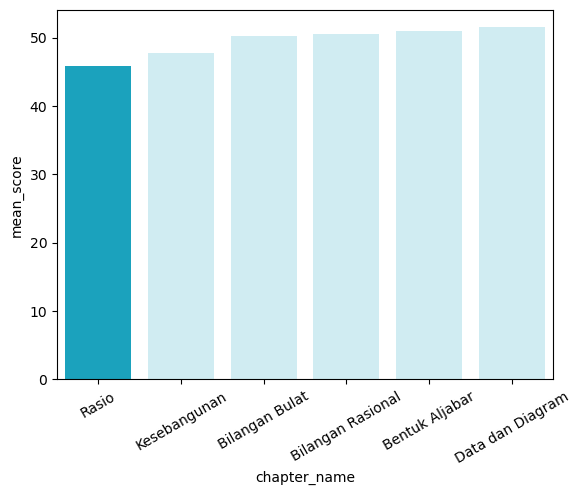

In [160]:
colors = ['#00b4d8', '#caf0f8', '#caf0f8', '#caf0f8', '#caf0f8', '#caf0f8' ]
sns.barplot(
    data=groupby_chapter,
    x='chapter_name',
    y='mean_score',
    hue='chapter_name',
    palette=colors
)
plt.xticks(rotation=30)
plt.show()

**Insight:**
- Rasio merupakan bab yang memiliki skor rata-rata terendah dibanding 5 bab lainnya
- Data dan Diagram justru menjadi bab yang mendapatkan rata-rata tertinggi diantara bab lainnya. Meskipun rata-rata skornya masih tergolong rendah

### Pertanyaan 2: Bagaimana persentase distribusi tingkat kompetensi siswa (beginner, intermediate, advanced) pada seluruh sub-bab secara kumulatif selama tahun 2026? 

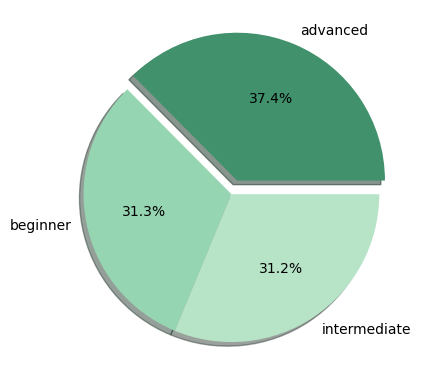

In [161]:
explode = [0.1, 0, 0]

colors = ['#40916c', '#95d5b2', '#b7e4c7']

plt.pie(
    x=groupby_current_level['percentage'],
    labels=groupby_current_level['current_level'],
    colors=colors,
    autopct='%1.1f%%',
    explode=explode,
    shadow=True
)
plt.show()

**Insight:**
- Dari total 1000 siswa, sebagian besar siswa sudah tergolong advanced pada kategori current levelnya.
- Artinya, sudah lumayan banyak siswa yang menguasai materi Matematika Kelas 7
- Selain itu, jumlah siswa yang memiliki current levelnya beginner dan intermediate, hampir sama. Hanya berbeda sekitar 0.1% saja

### Pertanyaan 3: Bab (chapter) mana yang memiliki tingkat penyelesaian dengan status 'done' tertinggi dibandingkan dengan total bab yang diambil oleh siswa pada tahun 2026? 

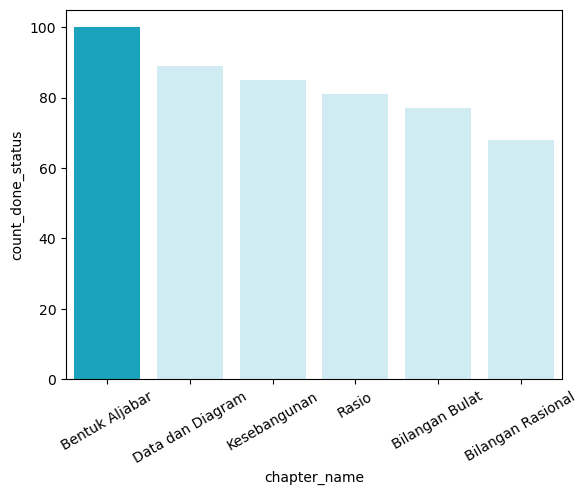

In [162]:
colors = ['#00b4d8', '#caf0f8', '#caf0f8', '#caf0f8', '#caf0f8', '#caf0f8' ]

sns.barplot(
    data=groupby_status_chapter,
    x=groupby_status_chapter['chapter_name'],
    y=groupby_status_chapter['count_done_status'],
    hue=groupby_status_chapter['chapter_name'],
    palette=colors
)
plt.xticks(rotation=30)
plt.show()

**Insight:**
- Bentuk aljabar merupakan bab yang sudah banyak diselesaikan kelasnya oleh sekitar 100 siswa, dari 1000 siswa
- Bisa jadi, bab tersebut memang merupakan bab yang mudah dipahami atau bab yang memiliki materi paling sedikit. Sehingga banyak siswa cepat menyelesaikan bab itu
- Sebaliknya, bilangan rasional merupakan bab yang tingkat status done terendah
- Hal ini bisa disebabkan karena jumlah materi yang padat atau materi yang terlalu sulit, sehingga siswa melewati bab tersebut untuk dipelajari lebih lanjut

### Pertanyaan 4: Sub-bab mana yang paling banyak membuat siswa stuck, memiliki status 'in-progress' dalam durasi yang lama selama tahun 2026?

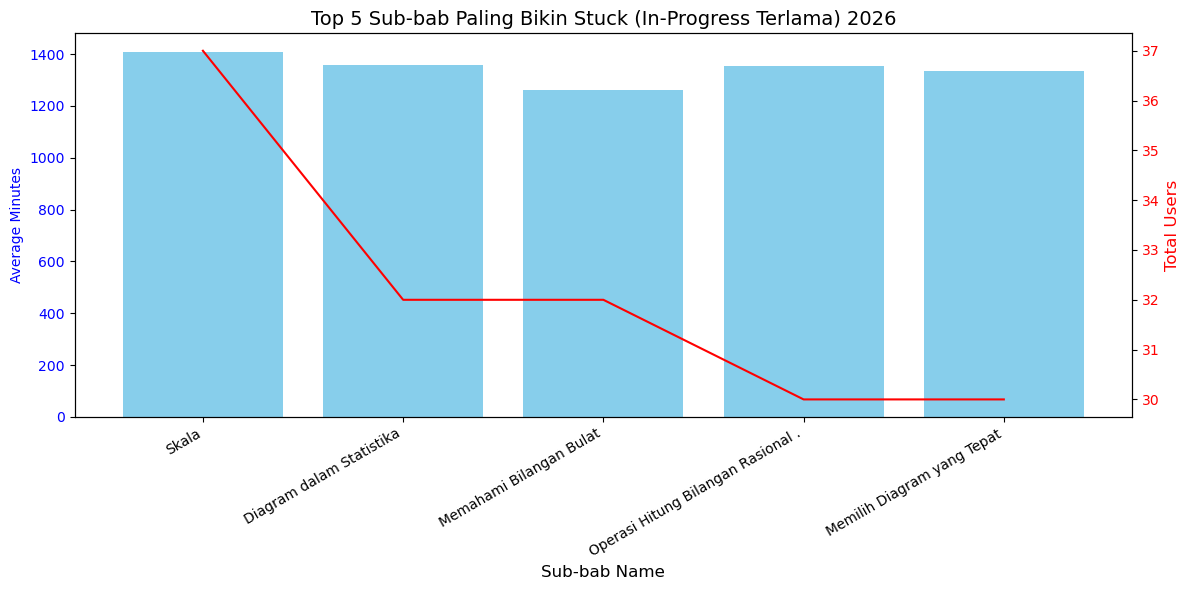

In [163]:
top_5_stuck = groupby_subchapter.head(5)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar Chart untuk durasi menit (Sumbu Y kiri)
ax1.bar(top_5_stuck['subchapter_name'], top_5_stuck['diff_progress_minutes'], color='skyblue', label='Avg Minutes Stuck')
ax1.set_ylabel('Average Minutes', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Sub-bab Name', fontsize=12)

plt.xticks(rotation=30, ha='right')

# Total user disimpan sumbu Y kanan (kedua)
ax2 = ax1.twinx()
ax2.plot(top_5_stuck['subchapter_name'], top_5_stuck['total_user'], color='red', label='Total Users')
ax2.set_ylabel('Total Users', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Top 5 Sub-bab Paling Bikin Stuck (In-Progress Terlama) 2026', fontsize=14)
fig.tight_layout()
plt.show()


**Insight:**
- Visualisasi ini mengatakan bahwa 5 bab tersebut merupakan sub-bab yang paling banyak membuat mereka stuck dalam status in-progress
- Selain membuat stuck, sub-bab tersebut juga merupakan sub-bab yang memiliki waktu yang lama untuk stuck di in-progress
- Hal ini bisa disebabkan oleh beberapa kemungkinan. Bisa saja karena materinya yang terlalu sulit, banyak, atau banyak siswa yang belum memahami materi prasyaratnya

### Pertanyaan 5: Bagaimana perbandingan rata-rata skor siswa pada assessment bertipe 'placement' (tes diagnostik/awal) dibandingkan dengan rata-rata skor pada tipe 'exam' di setiap bab (chapter) selama tahun 2026?

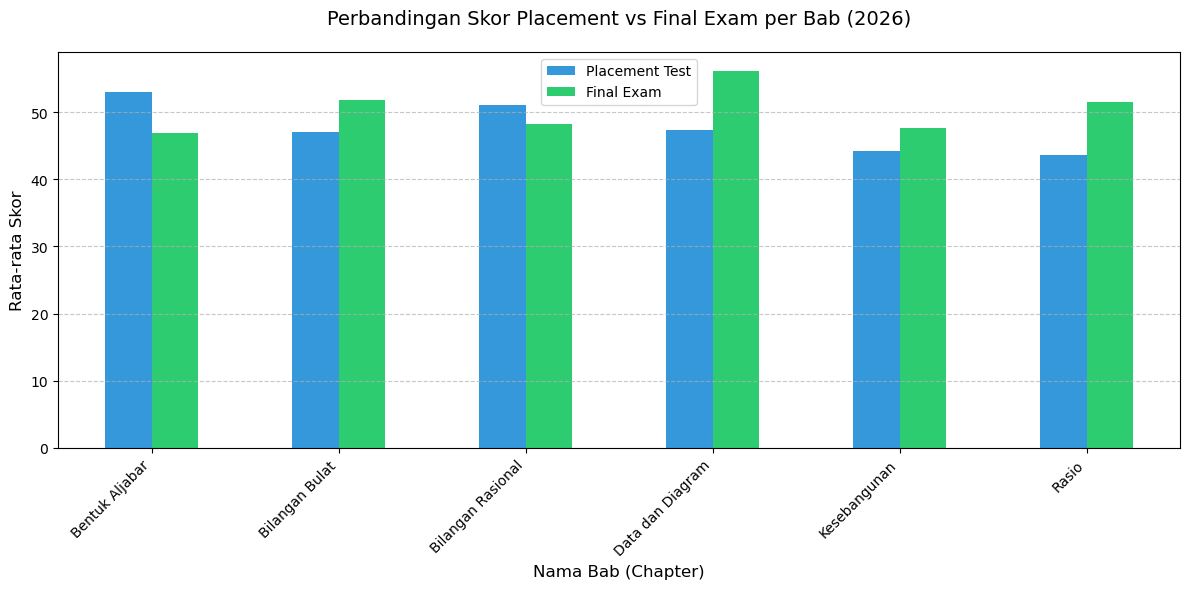

In [164]:
ax = groupby_chapter_type.plot(
    x='name', 
    y=['mean_score_placement', 'mean_score_exam'], 
    kind='bar', 
    figsize=(12, 6),
    color=['#3498db', '#2ecc71'] # Biru untuk awal, Hijau untuk akhir
)

plt.title('Perbandingan Skor Placement vs Final Exam per Bab (2026)', fontsize=14, pad=20)
plt.ylabel('Rata-rata Skor', fontsize=12)
plt.xlabel('Nama Bab (Chapter)', fontsize=12)
plt.legend(['Placement Test', 'Final Exam'])
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Insight:**
- 4 dari 6 bab, siswa mengalami kenaikan nilai pada final exam, dibanding saat fase placement. Hal ini menandakan bahwa siswa tersebut berhasil memahami materinya itu dengan baik.
- Namun 2 sisanya justru mengalami penurunan nilai saat fase placement dan fase final exam. Hal ini perlu dievaluasi lebih lanjut oleh guru nya

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis data tahun 2026, bab Rasio merupakan materi dengan capaian rata-rata skor terendah, yaitu sebesar 45.81. Namun, temuan krusial menunjukkan bahwa seluruh bab Matematika kelas 7 memiliki rata-rata skor yang rendah (di bawah 52.00). Hal ini mengindikasikan adanya kendala pemahaman konsep dasar secara masif pada mayoritas siswa atau terdapat ketidakseimbangan antara tingkat kesulitan soal dengan level kompetensi siswa saat ini.
- **Conclusion pertanyaan 2:** Terdapat inkonsistensi logika antara klasifikasi tingkat kompetensi dengan realita performa siswa. Meskipun persentase siswa Advanced merupakan yang tertinggi (37.44%), temuan ini bertolak belakang dengan rata-rata skor siswa di seluruh bab yang hanya berkisar di angka 45.81 - 51.52. Hal ini menunjukkan bahwa ambang batas (threshold) yang digunakan sistem untuk melabeli siswa sebagai 'Advanced' terlalu rendah dan tidak mencerminkan penguasaan materi yang sebenarnya.
- **Conclusion pertanyaan 3:** Bab Bentuk Aljabar mencatatkan tingkat penyelesaian tertinggi dengan 100 status 'Done'. Namun, tingginya angka penyelesaian ini tidak berbanding lurus dengan tingkat penguasaan, di mana rata-rata skornya hanya 51.01. Fenomena sebaliknya terjadi pada bab Bilangan Rasional; meskipun memiliki rata-rata skor yang relatif tinggi (50.49), jumlah siswa yang menyelesaikannya adalah yang terendah (68 siswa). Hal ini mengindikasikan adanya kecenderungan siswa untuk "sekadar menyelesaikan" materi yang dianggap populer (Aljabar) namun menghindari atau kesulitan merampungkan materi yang dianggap teknis (Rasional).
- **Conclusion pertanyaan 4:** Sub-bab Skala diidentifikasi sebagai titik hambat (major bottleneck) terbesar bagi siswa selama tahun 2026. Tercatat sebanyak 37 siswa terjebak dalam status 'In-Progress' dengan durasi rata-rata mencapai 1409.64 menit (sekitar 23,5 jam). Temuan ini mengindikasikan adanya kesulitan kognitif yang ekstrem pada materi tersebut atau adanya ketidakjelasan instruksi pengerjaan yang menyebabkan siswa menunda penyelesaian tugas hingga berhari-hari.
- **Conclusion pertanyaan 5:** Aplikasi menunjukkan performa positif pada 66.6% materi pembelajaran, di mana 4 dari 6 bab mencatatkan kenaikan skor dari fase placement ke final exam. Kenaikan tertinggi terjadi pada bab Data dan Diagram (+8.9 poin) dan Rasio (+7.9 poin). Namun, ditemukan penurunan performa (Learning Loss) pada bab Bentuk Aljabar dan Bilangan Rasional, yang mengindikasikan ketidakselarasan antara materi yang diajarkan dengan bobot ujian akhir pada kedua bab tersebut.

**Rekomendasi Action Item:**
- **Pertanyaan 1:** 
    1. Evaluasi Bank Soal: Segera lakukan audit terhadap 186 percobaan kuis yang sudah masuk. Cek apakah soal-soal di bab Rasio dan Kesebangunan memiliki label difficulty level yang sesuai. Jika soal 'Medium' terasa seperti 'Hard', maka perlu dilakukan kalibrasi ulang bobot soal.
    2. Intervensi Materi Prasyarat: Mengingat skor di bab Rasio rendah, tim AI perlu mengoptimalkan fitur Prerequisite Gap Detection. AI harus mampu mendeteksi apakah rendahnya skor Rasio disebabkan karena siswa belum tuntas di materi 'Bilangan Bulat' atau 'Operasi Pecahan', lalu memberikan rekomendasi materi dasar secara otomatis.
    3. Pengembangan Konten Interaktif: Khusus untuk bab dengan skor di bawah 50 (Rasio & Kesebangunan), disarankan untuk menambahkan alat peraga visual atau video simulasi interaktif. Materi berbasis hafalan rumus harus diganti dengan pendekatan logika visual untuk membantu siswa melampaui skor 45 tersebut.
    4. Fitur Remedial Terpandu: Implementasikan fitur Remedial Pathway di aplikasi. Siswa yang mendapatkan skor di bawah 50 pada bab Rasio tidak diperbolehkan lanjut ke bab berikutnya sebelum menyelesaikan modul penguatan konsep dasar yang direkomendasikan oleh AI.
- **Pertanyaan 2:** 
    1. Rekalibrasi Threshold Level: Segera tinjau ulang kodingan pada bagian penentuan level. Disarankan untuk mengubah standar nilai:
    - Beginner: Skor 0 - 59
    - Intermediate: Skor 60 - 79
    - Advanced: Skor 80 - 100
    2. Audit Algoritma Klasifikasi: Mengecek apakah label 'Advanced' diberikan hanya berdasarkan jumlah bab yang diselesaikan (completion) atau benar-benar berdasarkan nilai ujian (mastery). Sistem harus mengutamakan kualitas nilai daripada kuantitas pengerjaan.
    3. Sinkronisasi Standar Akademik: Melakukan penyesuaian label kompetensi agar selaras dengan KKM (Kriteria Ketuntasan Minimal) yang berlaku di jenjang SMP, sehingga laporan perkembangan siswa di aplikasi menjadi kredibel bagi orang tua dan guru.
    4. Fitur "Downgrade" Level Otomatis: Jika siswa yang sudah berstatus Advanced mendapatkan skor di bawah 60 pada kuis terbaru, sistem AI harus mampu menurunkan status kompetensinya kembali ke Intermediate agar siswa termotivasi untuk melakukan penguatan materi kembali.
- **Pertanyaan 3:** 
    1. Redefinisi Status 'Done': Mengubah kriteria penyelesaian bab. Status 'Done' sebaiknya hanya diberikan jika siswa mencapai skor minimal (misal: 70). Jika skor di bawah 70, status tetap 'In-Progress' atau 'Need Review' agar siswa tidak terjebak dalam kemajuan semu.
    2. Engagement Campaign untuk Bilangan Rasional: Melakukan audit pada bab Bilangan Rasional. Cari tahu apakah jumlah sub-bab di sana terlalu banyak atau membosankan sehingga siswa berhenti di tengah jalan. Tambahkan elemen gamifikasi atau instruksi yang lebih sederhana untuk meningkatkan retensi siswa.
    3. Mastery Over Completion: Guru disarankan untuk memberikan penguatan khusus pada konsep Aljabar. Walaupun secara sistem siswa sudah 'Done', guru harus menyadari bahwa secara kualitas, pemahaman mereka masih di angka 50-an.
    4. Fitur Nudging: Implementasikan fitur pengingat (automated nudging) bagi siswa yang sudah memulai bab Bilangan Rasional tetapi belum menyelesaikannya dalam waktu 1 minggu, guna meningkatkan angka penyelesaian bab tersebut.
- **Pertanyaan 4:** 
    1. Audit UX & Session Timeout: Mengecek apakah sistem penghitungan waktu tetap berjalan saat aplikasi tidak aktif. Jika ya, tim harus mengimplementasikan fitur Auto-Pause atau Session Timeout agar data durasi tidak terdistorsi oleh siswa yang lupa menutup aplikasi.
    2. Simplifikasi Konten Skala: Mengingat durasi yang sangat lama, materi Skala perlu dipecah menjadi bagian-bagian yang lebih kecil (micro-learning). Tambahkan alat bantu hitung digital atau kalkulator konversi satuan di dalam modul untuk mengurangi beban kognitif siswa.
    3. Targeted Discussion: Guru disarankan melakukan sesi diskusi khusus untuk 37 siswa yang terdeteksi stuck di materi Skala. Fokuskan pada cara mengubah satuan (cm, m, km) yang sering kali menjadi penyebab utama kebingungan siswa.
- **Pertanyaan 5:** 
    1. Item Analysis & Calibration: Segera lakukan audit pada bank soal bab Bentuk Aljabar. Bandingkan tingkat kesulitan soal placement dengan final exam. Jika soal exam terlalu sulit, tim DS harus melakukan kalibrasi ulang bobot soal agar penilaian lebih adil.
    2. Instructional Design Review: Melakukan peninjauan ulang terhadap modul video dan latihan pada bab Bentuk Aljabar. Mengingat skor siswa justru menurun, disarankan untuk menyederhanakan penjelasan konsep variabel dan konstanta dengan metode yang lebih intuitif atau konkret.
    3. Adaptive Intervention: Mengoptimalkan algoritma Adaptive Learning. Bagi siswa yang mencatatkan skor placement lebih tinggi daripada skor progress harian pada bab Bentuk Aljabar, AI harus memberikan peringatan dini (warning) dan menyarankan materi penguatan sebelum mereka diperbolehkan mengambil final exam.
    4. Replikasi Keberhasilan: Menganalisis pola penyampaian materi pada bab Data dan Diagram yang sukses menghasilkan kenaikan skor tertinggi, untuk kemudian diaplikasikan pada struktur bab-bab lainnya yang masih memiliki pertumbuhan rendah.